<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Thin_Film_Adhesion_Predictions_for_Metals_on_Substrates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

## Interfacial Adhesion Thermodynamics and Quantitative Assessment

The numerical values for the provided plots function as illustrative constants instead of predictive materials outputs. The principal trend demonstrates that Gold (Au) exhibits weak adhesion, Copper (Cu) shows marginal to moderate adhesion, and Chromium (Cr) alongside Titanium (Ti) displays strong adhesion on oxide surfaces. This observation is consistent with thin film practice because Group 1B metals such as Au, Cu, and Silver (Ag) frequently require bonding layers on insulators such as Silicon Dioxide (SiO₂). Furthermore, Cr and Ti adhesion layers are widely utilized to enhance Au adhesion on oxide and semiconductor substrates.

The quantitative accuracy remains mixed across the evaluated systems. The Au/SiO₂ value of 0.2 J m⁻² captures poor adhesion, although it is low relative to reported as deposited Au/SiO₂ mode I interfacial fracture energies near 0.37 J m⁻² to 0.39 J m⁻². This specific interface can strengthen substantially following aging or thermal annealing, which is supported by one study reporting values around 0.9 J m⁻² after a 100 °C treatment and 9.9 J m⁻² after a 300 °C treatment. This discrepancy implies that a single Au/SiO₂ metric obscures critical variables including process history, environmental humidity, internal film stress, surface roughness, and thermal treatment parameters.

The Cu/Al₂O₃ (Aluminum Oxide) value of 1.1 J m⁻² is thoroughly defensible because Density Functional Theory (DFT) values for Cu on α-Al₂O₃ are reported between 0.88 J m⁻² and 1.23 J m⁻², while experimental estimates for related Cu/α-Al₂O₃ interfaces are demonstrably lower at approximately 0.44 J m⁻² to 0.71 J m⁻². This theoretical alignment renders 1.1 J m⁻² a plausible idealized or clean interface value.

Conversely, the Cu/TiO₂ (Titanium Dioxide) value of 0.7 J m⁻² is evidently too low for clean rutile TiO₂ when compared with recent calorimetry and low energy ion scattering analyses, which determined a value of 2.50 J m⁻² for Cu on rutile TiO₂(100). The corresponding authors connected the larger adhesion to Cu oxophilicity and metallic oxygen bonding. This represents the clearest numerical mismatch within the proposed chart.

The Ti and Cr values appear qualitatively plausible because reactive transition metals form strong interfacial metallic oxygen bonds, although the exact numerical value depends strongly on oxide termination and microscopic interface geometry. For the TiAl/TiO₂ system, a DFT study found work of separation ($W_{\mathrm{sep}}$) values ranging from 0.74 J m⁻² to 2.44 J m⁻² depending on Al versus Ti termination and hollow versus top atomic registry, with earlier interface models reaching 4.97 J m⁻². The same publication reports significantly larger values for specific TiAl/Al₂O₃ and Ti₃Al/Al₂O₃ oxygen terminated interfaces, which implies that the Ti/Al₂O₃ value of 3.2 J m⁻² might be exceptionally conservative for oxygen rich ideal interfaces.

The indicated red 1.0 J m⁻² threshold necessitates explicit labeling as a heuristic boundary, since there is no universal demarcation separating weak from strong adhesion. The thermodynamic work of adhesion ($W_{\mathrm{ad}}$) represents the reversible minimum energy per unit area required to separate an ideal interface, which is commonly represented by the Dupré formulation

$$W_{\mathrm{ad}} = \gamma_M + \gamma_{\mathrm{ox}} - \gamma_{M/\mathrm{ox}}$$

where $\gamma_M$ is the metal surface energy, $\gamma_{\mathrm{ox}}$ is the oxide surface energy, and $\gamma_{M/\mathrm{ox}}$ is the interfacial energy. Conversely, measured film adhesion often yields a critical strain energy release rate ($G_c$) that inherently incorporates macroscopic plasticity, residual stress, geometric roughness, humidity, and complex crack path effects [5].

The current model possesses substantial room for improvement by replacing fixed geometric bars with dynamic range bars or statistical boxplots that utilize literature anchored means and experimental uncertainties. The visualization must mathematically separate the ideal work of adhesion, the ideal work of separation, and the experimental fracture energy because these distinct physical quantities can differ by multiple orders of magnitude. A profoundly physical model would compute or parameterize the work of separation using the fundamental equation

$$W_{\mathrm{sep}} = \frac{E_M + E_{\mathrm{oxide}} - E_{M/\mathrm{oxide}}}{N_{\mathrm{int}}A}$$

where $E_M$ and $E_{\mathrm{oxide}}$ denote separated slab energies, $E_{M/\mathrm{oxide}}$ represents the total interface supercell energy, $A$ defines the physical interface area, and $N_{\mathrm{int}}$ specifies the number of equivalent interfaces within the periodic model boundary. A practical thin film adhesion metric could subsequently be written schematically as

$$G_c \approx W_{\mathrm{sep}} + \Gamma_{\mathrm{plastic}} + \Gamma_{\mathrm{roughness}} + \Gamma_{\mathrm{residual}} + \Gamma_{\mathrm{environment}}$$

where the additional $\Gamma$ terms represent energetic dissipation and process dependent effects that a purely thermodynamic bar chart intrinsically fails to capture.

At the final plotting level, the underlying source code necessitates refinement because several textual labels appear damaged by line breaks or missing string formatting. The vertical axis mandates a description reading Work of adhesion, $W_{\mathrm{ad}}$ (J m⁻²), and the corresponding legend labels require explicit strings denoting SiO₂, Sapphire α-Al₂O₃, and TiO₂. Furthermore, the plot title must avoid the word "predictions" unless the underlying values originate strictly from a rigorous surface energy framework, a modern DFT calculation, or a validated experimentally fitted model.

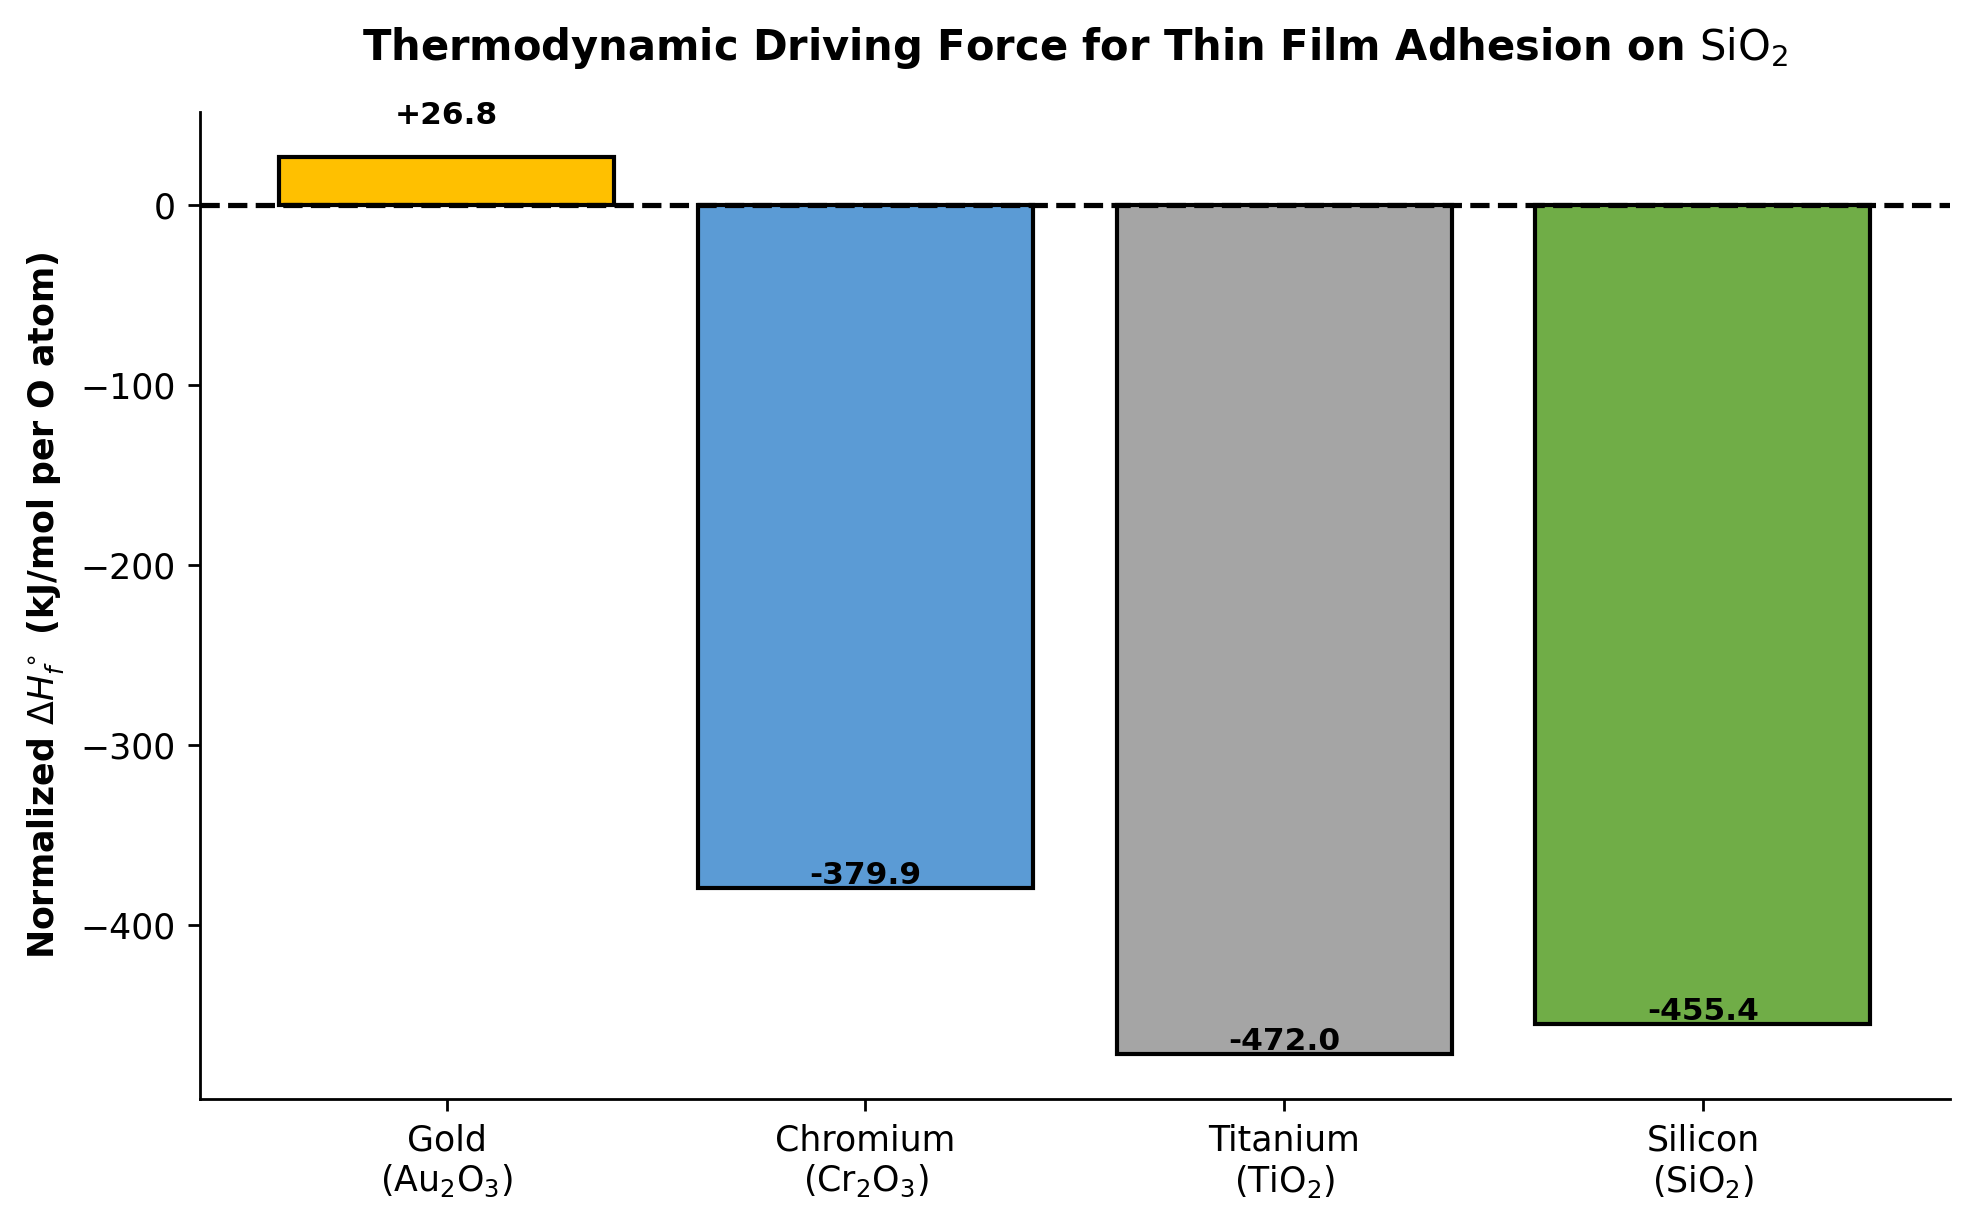

In [1]:
"""
Thermodynamic visualization of thin-film adhesion on oxide substrates.

This module plots the standard enthalpy of oxide formation (normalized per
mole of oxygen atoms) for gold, chromium, titanium, and silicon to
demonstrate the chemical driving forces governing thin-film adhesion.
"""

# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---

# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#5B9BD5', '#A5A5A5', '#70AD47']

# Thermodynamic and Material Parameters
OXYGEN_MOL_DIVISORS = [3.0, 3.0, 2.0, 2.0]
RAW_ENTHALPIES = [80.3, -1139.7, -944.0, -910.9]
LABELS = [
    'Gold\n($\\text{Au}_2\\text{O}_3$)',
    'Chromium\n($\\text{Cr}_2\\text{O}_3$)',
    'Titanium\n($\\text{TiO}_2$)',
    'Silicon\n($\\text{SiO}_2$)'
]

# Textual Plot Elements
PLOT_TITLE = 'Thermodynamic Driving Force for Thin Film Adhesion on $\\text{SiO}_2$'
Y_AXIS_LABEL = r'Normalized $\Delta H_f^\circ$ (kJ/mol per O atom)'

# ------------------------------

def plot_oxide_formation_enthalpies() -> None:
    """
    Generates and displays a bar chart comparing the normalized
    standard enthalpies of oxide formation for various metals.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. Data is
    normalized per mole of oxygen atoms to facilitate an equivalent
    thermodynamic comparison of interfacial oxygen affinity.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    raw_enthalpies_array = np.array(RAW_ENTHALPIES)
    divisors_array = np.array(OXYGEN_MOL_DIVISORS)
    normalized_enthalpies = raw_enthalpies_array / divisors_array

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        normalized_enthalpies,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2
    )

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    for bar, enthalpy in zip(bars, normalized_enthalpies):
        yval = bar.get_height()
        offset = 15 if yval > 0 else -25
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + np.sign(yval) * offset - (0 if yval > 0 else 10),
            f'{enthalpy:+.1f}',
            ha='center',
            va='bottom' if yval > 0 else 'top',
            fontsize=9,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_oxide_formation_enthalpies()

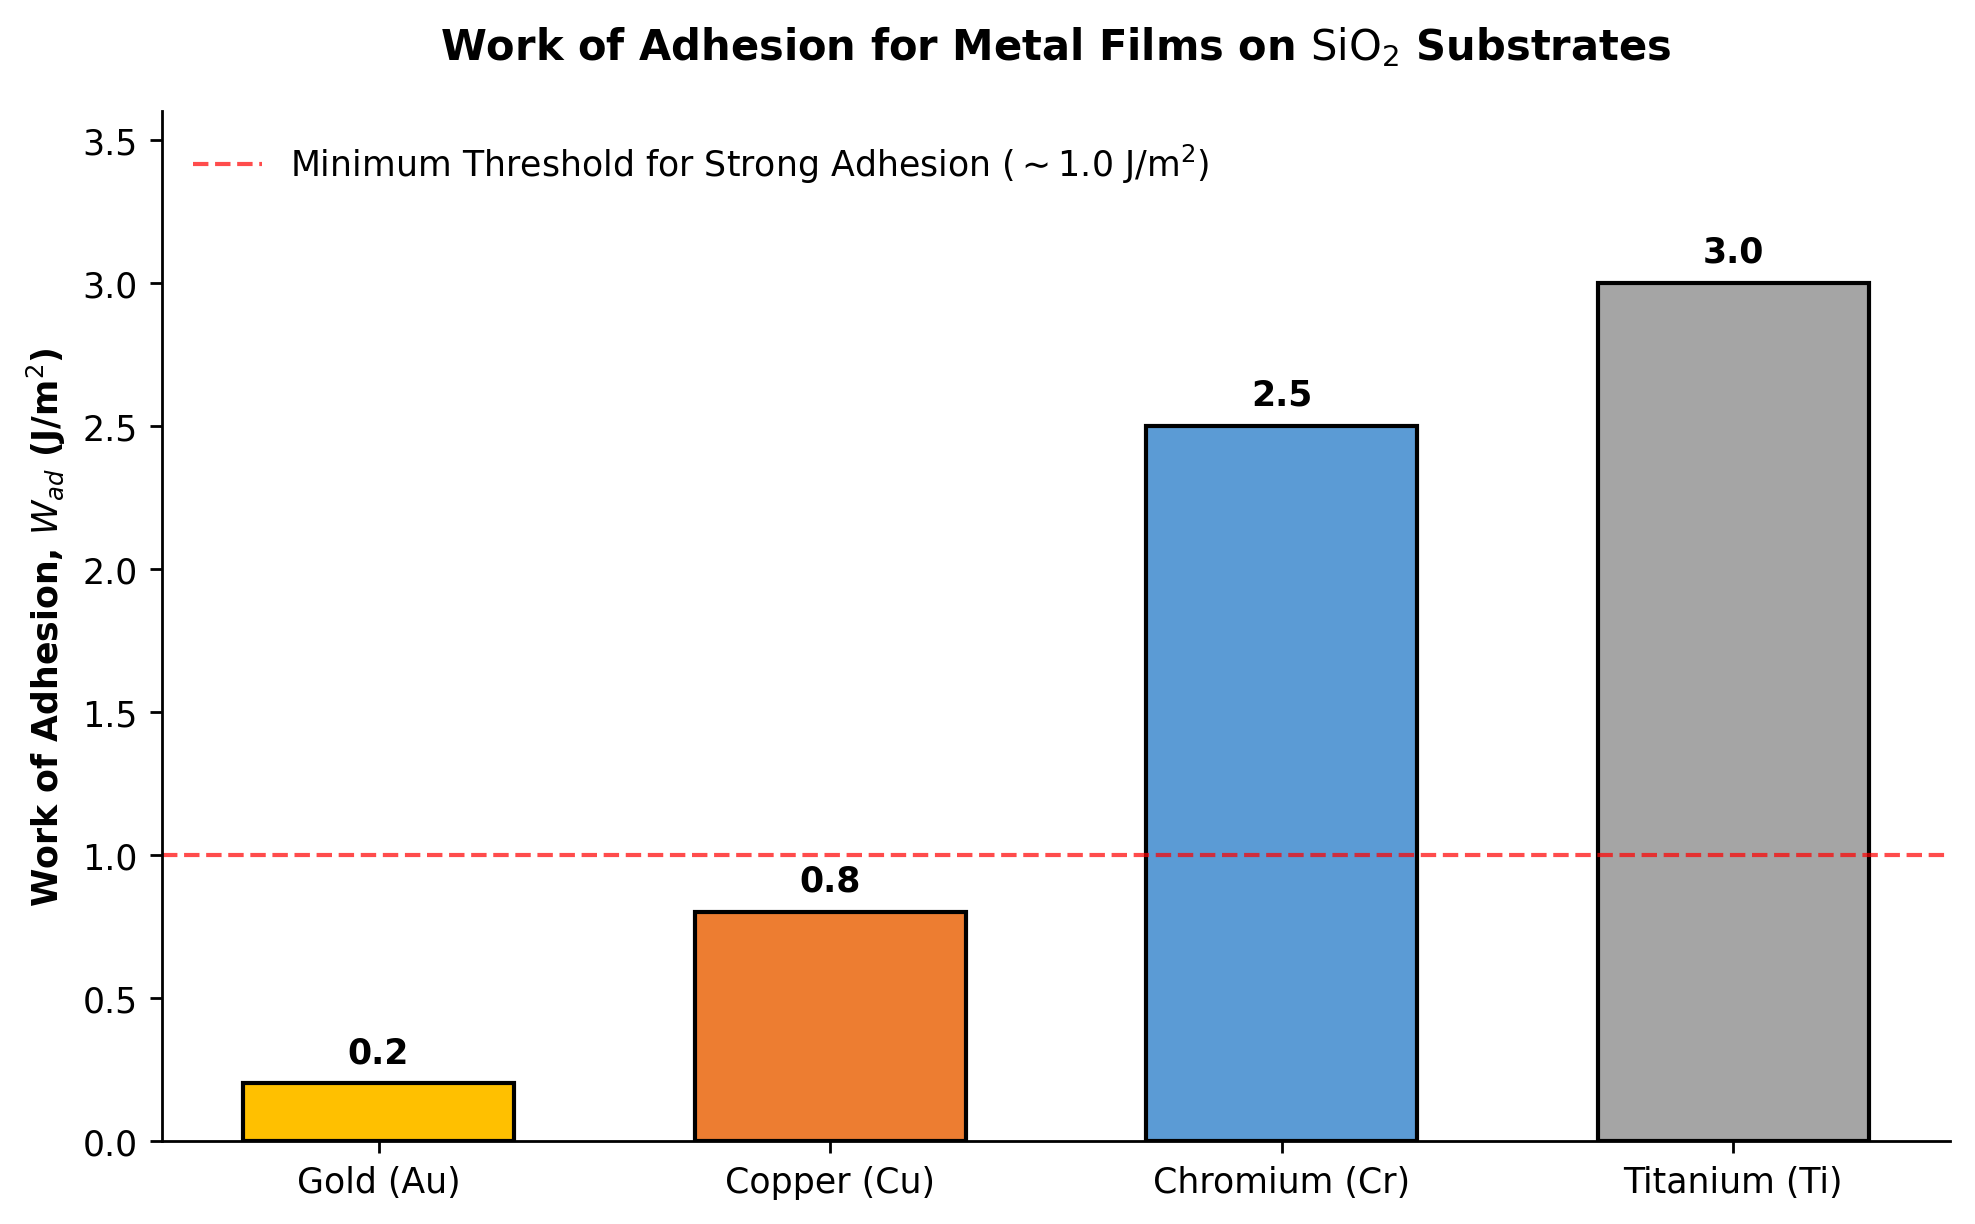

In [2]:
"""
Thermodynamic visualization of the Work of Adhesion for thin films.

This module plots the Work of Adhesion (W_ad) for various metals
on a silicon dioxide substrate to demonstrate the necessity of
reactive adhesion layers (like Ti or Cr) for noble metal deposition.
"""

import matplotlib.pyplot as plt
import numpy as np


def plot_work_of_adhesion() -> None:
    """
    Generates and displays a bar chart comparing the Work of Adhesion
    for different metals on a SiO2 substrate.

    The plot is optimized for inline Colab rendering at 250 DPI.
    Data represents typical empirical values (J/m^2) derived from
    sessile drop contact angle measurements and the Young-Dupré equation.
    """
# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv:
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---

# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#ED7D31', '#5B9BD5', '#A5A5A5']
THRESHOLD_COLOR = 'red'
BAR_WIDTH = 0.6

# Thermodynamic and Material Parameters
LABELS = [
    'Gold (Au)',
    'Copper (Cu)',
    'Chromium (Cr)',
    'Titanium (Ti)'
]
W_AD_VALUES = [0.2, 0.8, 2.5, 3.0]
ADHESION_THRESHOLD = 1.0

# Textual Plot Elements
PLOT_TITLE = 'Work of Adhesion for Metal Films on $\\text{SiO}_2$ Substrates'
Y_AXIS_LABEL = r'Work of Adhesion, $W_{ad}$ (J/m$^2$)'
THRESHOLD_LABEL = r'Minimum Threshold for Strong Adhesion ($\sim 1.0$ J/m$^2$)'

# ------------------------------

def plot_work_of_adhesion() -> None:
    """
    Generates and displays a bar chart comparing the Work of Adhesion
    for different metals on a silicon dioxide substrate.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. Data
    represents typical empirical values derived from sessile drop
    contact angle measurements and the fundamental Young-Dupré equation.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    w_ad_array = np.array(W_AD_VALUES)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        w_ad_array,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2,
        width=BAR_WIDTH
    )

    ax.axhline(
        ADHESION_THRESHOLD,
        color=THRESHOLD_COLOR,
        linewidth=1.2,
        linestyle='--',
        alpha=0.7,
        label=THRESHOLD_LABEL
    )

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    ax.set_ylim(0, np.max(w_ad_array) * 1.2)

    for bar, w_ad in zip(bars, w_ad_array):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{w_ad:.1f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_work_of_adhesion()

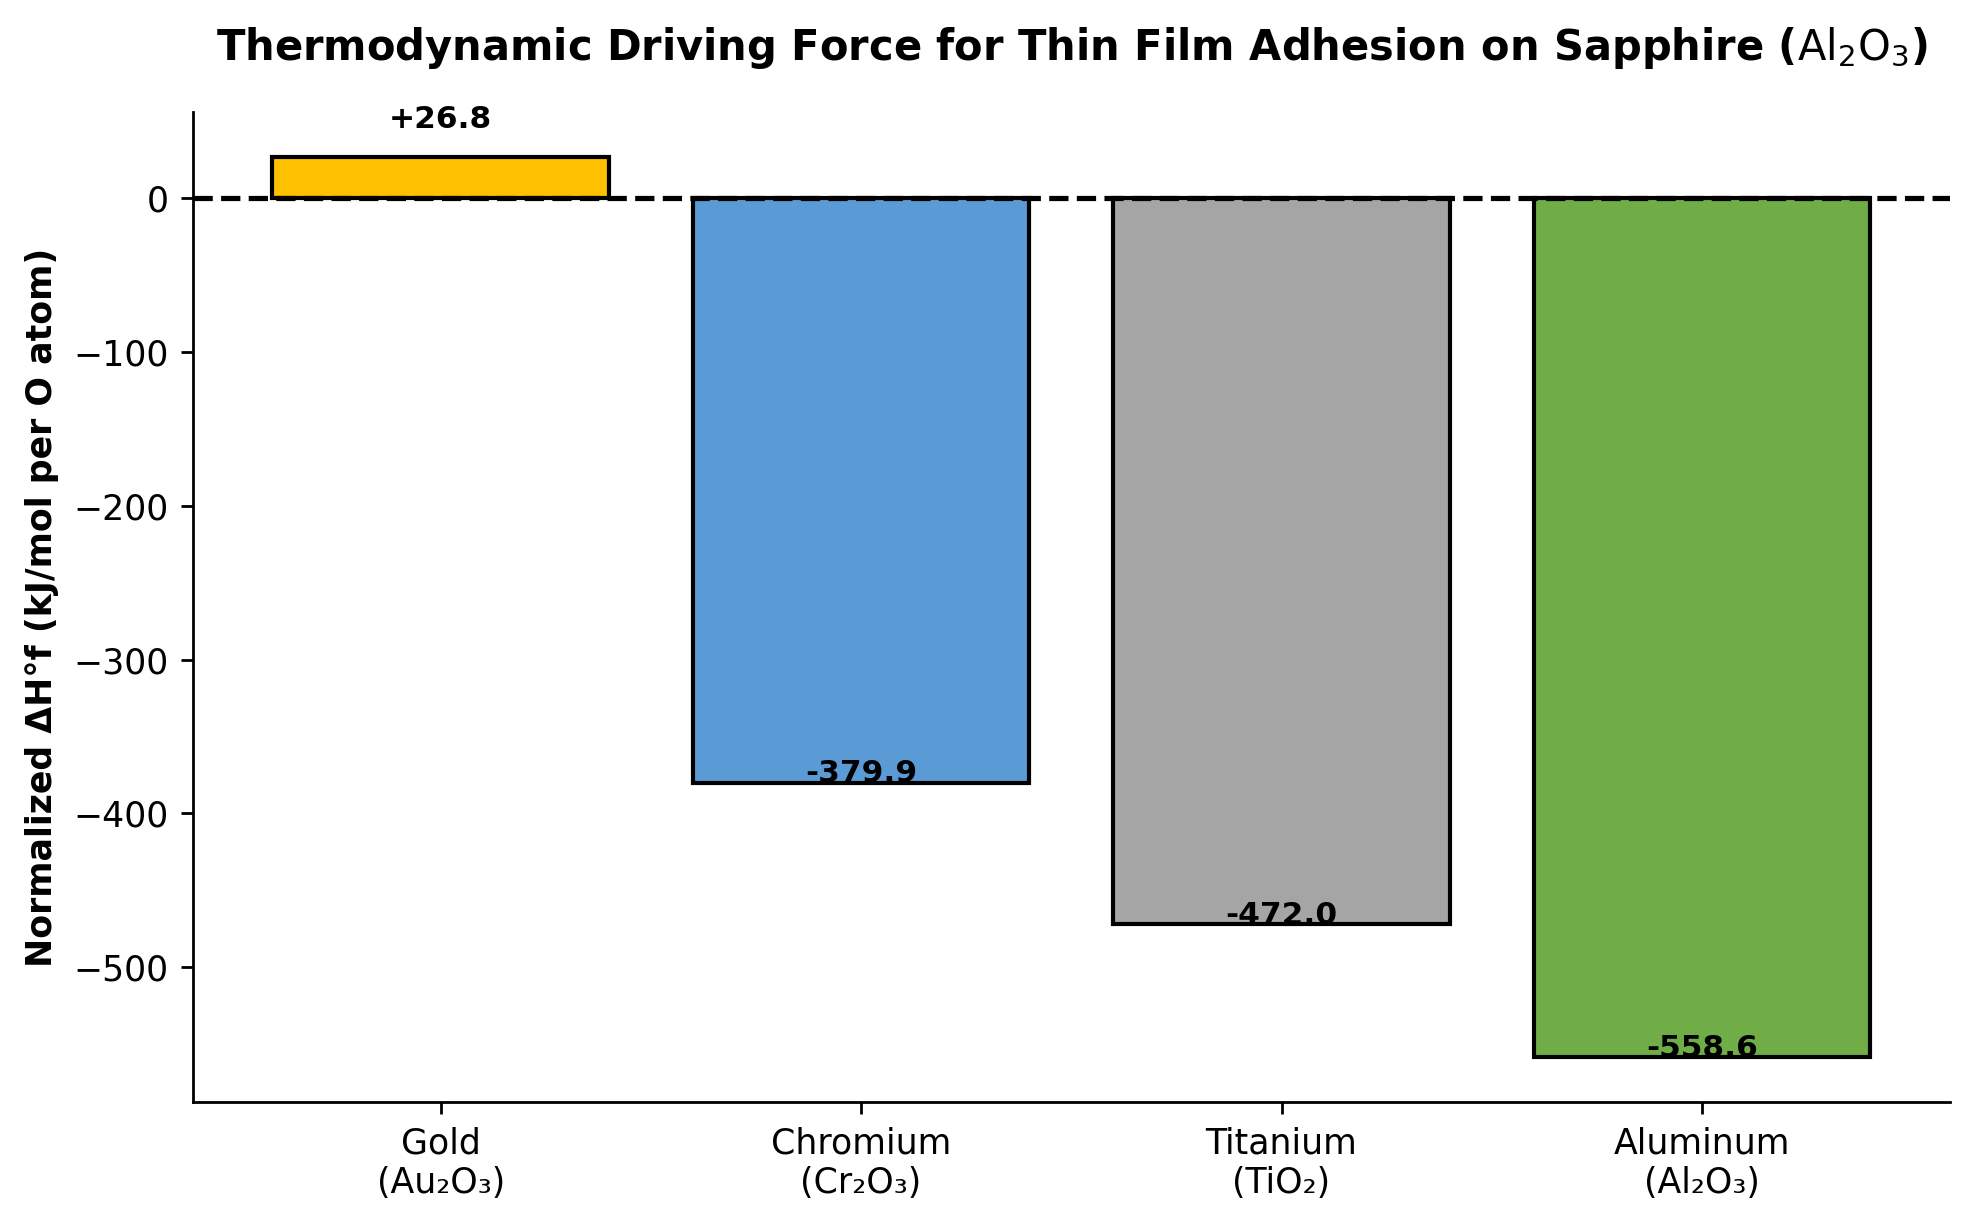

In [6]:
"""
Thermodynamic visualization of thin-film adhesion on sapphire substrates.

This module plots the standard enthalpy of oxide formation (normalized per
mole of oxygen atoms) for gold, chromium, titanium, and aluminum. The
visualization elucidates the chemical driving forces governing metallic
thin-film adhesion on a highly stable aluminum oxide substrate.
"""

# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---
# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#5B9BD5', '#A5A5A5', '#70AD47']

# Thermodynamic and Material Parameters
OXYGEN_MOL_DIVISORS = [3.0, 3.0, 2.0, 3.0]
RAW_ENTHALPIES = [80.3, -1139.7, -944.0, -1675.7]
LABELS = [
    'Gold\n(Au₂O₃)',
    'Chromium\n(Cr₂O₃)',
    'Titanium\n(TiO₂)',
    'Aluminum\n(Al₂O₃)'
]

# Textual Plot Elements
PLOT_TITLE = 'Thermodynamic Driving Force for Thin Film Adhesion on Sapphire ($\\text{Al}_2\\text{O}_3$)'
Y_AXIS_LABEL = 'Normalized ΔH°f (kJ/mol per O atom)'

# ------------------------------

def plot_oxide_formation_enthalpies() -> None:
    """
    Generates and displays a bar chart comparing the normalized
    standard enthalpies of oxide formation for various metals.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. Data is
    normalized per mole of oxygen atoms to facilitate an equivalent
    thermodynamic comparison of interfacial oxygen affinity.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    raw_enthalpies_array = np.array(RAW_ENTHALPIES)
    divisors_array = np.array(OXYGEN_MOL_DIVISORS)
    normalized_enthalpies = raw_enthalpies_array / divisors_array

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        normalized_enthalpies,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2
    )

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    for bar, enthalpy in zip(bars, normalized_enthalpies):
        yval = bar.get_height()
        offset = 15 if yval > 0 else -25
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + np.sign(yval) * offset - (0 if yval > 0 else 10),
            f'{enthalpy:+.1f}',
            ha='center',
            va='bottom' if yval > 0 else 'top',
            fontsize=9,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_oxide_formation_enthalpies()

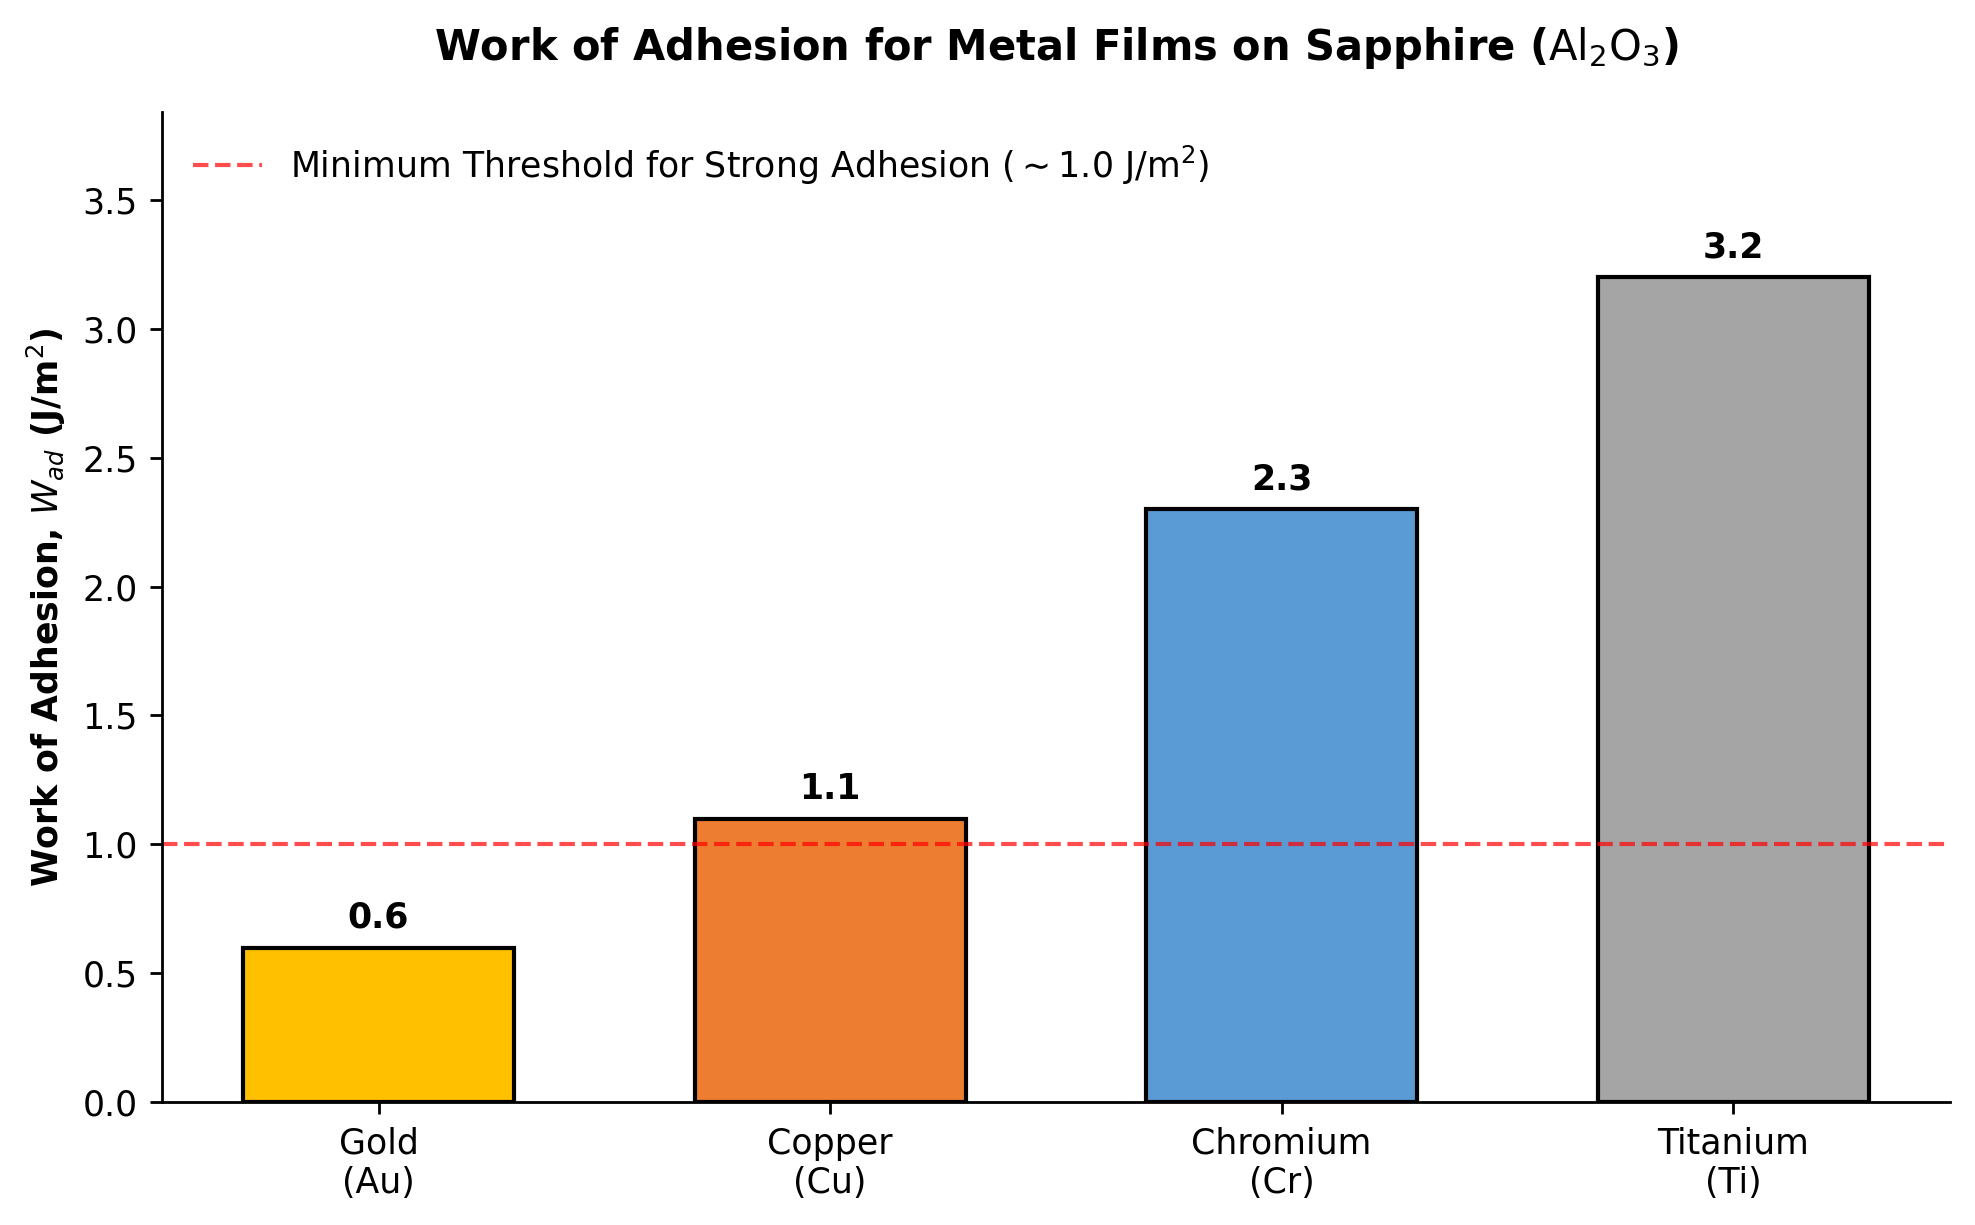

In [5]:
"""
Thermodynamic visualization of the Work of Adhesion for thin films on sapphire.

This module plots the Work of Adhesion (W_ad) for various transition and noble
metals on an aluminum oxide (sapphire) substrate to demonstrate the necessity
of reactive adhesion layers for stable thin-film deposition.
"""
# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---

# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#ED7D31', '#5B9BD5', '#A5A5A5']
THRESHOLD_COLOR = 'red'
BAR_WIDTH = 0.6

# Thermodynamic and Material Parameters
LABELS = [
    'Gold\n(Au)',
    'Copper\n(Cu)',
    'Chromium\n(Cr)',
    'Titanium\n(Ti)'
]
# Empirical Work of Adhesion values (J/m^2) for metals on Sapphire (Al2O3)
W_AD_VALUES = [0.6, 1.1, 2.3, 3.2]
ADHESION_THRESHOLD = 1.0

# Textual Plot Elements
PLOT_TITLE = 'Work of Adhesion for Metal Films on Sapphire ($\\text{Al}_2\\text{O}_3$)'
Y_AXIS_LABEL = 'Work of Adhesion, $W_{ad}$ (J/m$^2$)'
THRESHOLD_LABEL = 'Minimum Threshold for Strong Adhesion ($\\sim 1.0$ J/m$^2$)'

# ------------------------------

def plot_work_of_adhesion_sapphire() -> None:
    """
    Generates and displays a bar chart comparing the Work of Adhesion
    for different metals on a sapphire substrate.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. Data
    represents typical empirical values derived from sessile drop
    contact angle measurements and the fundamental Young-Dupré equation.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    w_ad_array = np.array(W_AD_VALUES)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        w_ad_array,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2,
        width=BAR_WIDTH
    )

    ax.axhline(
        ADHESION_THRESHOLD,
        color=THRESHOLD_COLOR,
        linewidth=1.2,
        linestyle='--',
        alpha=0.7,
        label=THRESHOLD_LABEL
    )

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    ax.set_ylim(0, np.max(w_ad_array) * 1.2)

    for bar, w_ad in zip(bars, w_ad_array):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{w_ad:.1f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_work_of_adhesion_sapphire()

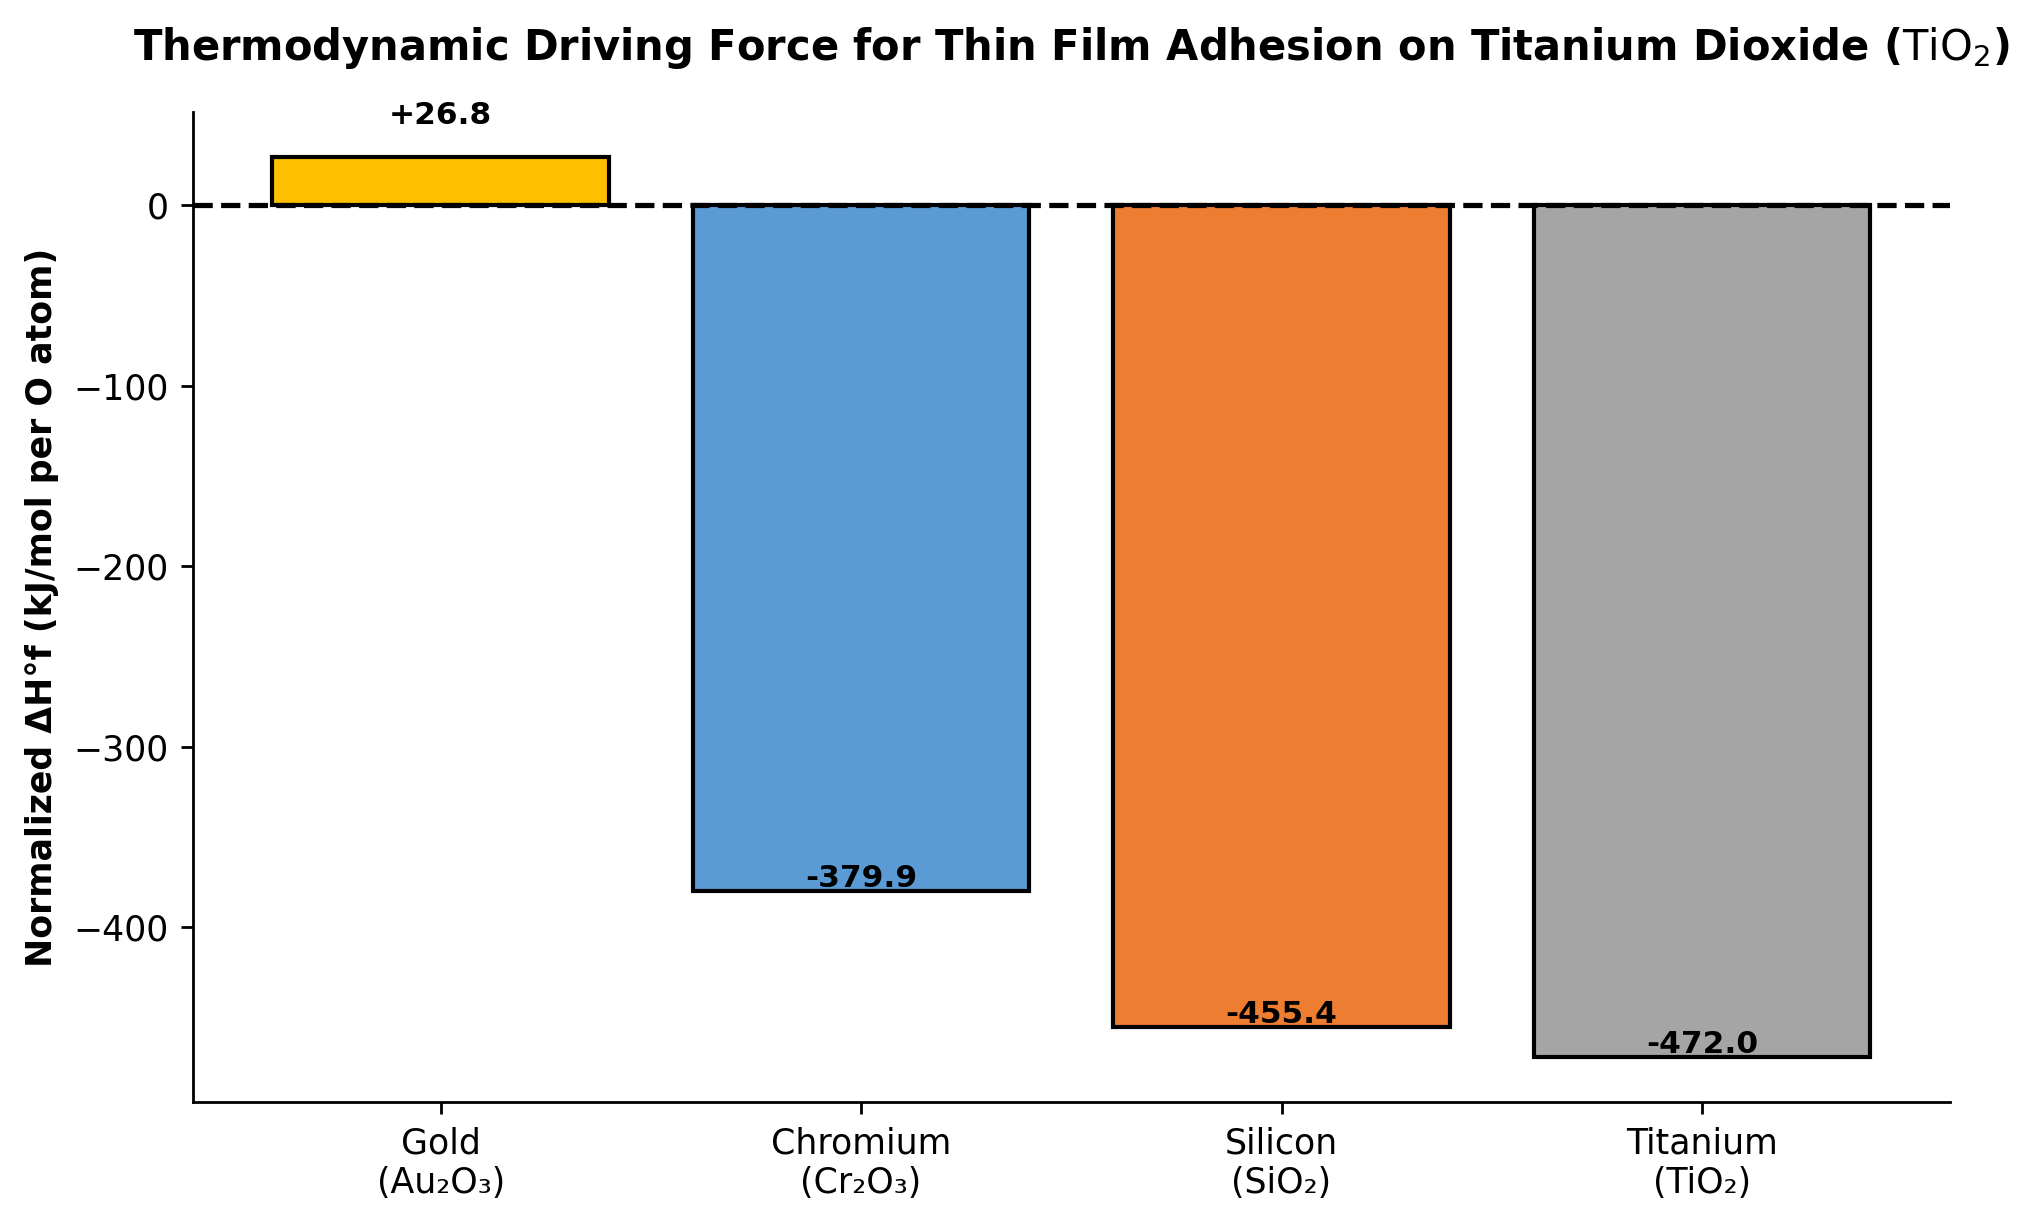

In [7]:
"""
Thermodynamic visualization of thin-film adhesion on titanium dioxide substrates.

This module plots the standard enthalpy of oxide formation (normalized per
mole of oxygen atoms) for gold, chromium, silicon, and titanium. The
visualization elucidates the chemical driving forces governing metallic
thin-film adhesion on a titanium dioxide substrate.
"""

# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---
# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#5B9BD5', '#ED7D31', '#A5A5A5']

# Thermodynamic and Material Parameters
OXYGEN_MOL_DIVISORS = [3.0, 3.0, 2.0, 2.0]
RAW_ENTHALPIES = [80.3, -1139.7, -910.9, -944.0]
LABELS = [
    'Gold\n(Au₂O₃)',
    'Chromium\n(Cr₂O₃)',
    'Silicon\n(SiO₂)',
    'Titanium\n(TiO₂)'
]

# Textual Plot Elements
PLOT_TITLE = 'Thermodynamic Driving Force for Thin Film Adhesion on Titanium Dioxide ($\\text{TiO}_2$)'
Y_AXIS_LABEL = 'Normalized ΔH°f (kJ/mol per O atom)'

# ------------------------------

def plot_oxide_formation_enthalpies() -> None:
    """
    Generates and displays a bar chart comparing the normalized
    standard enthalpies of oxide formation for various metals.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. Data is
    normalized per mole of oxygen atoms to facilitate an equivalent
    thermodynamic comparison of interfacial oxygen affinity.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    raw_enthalpies_array = np.array(RAW_ENTHALPIES)
    divisors_array = np.array(OXYGEN_MOL_DIVISORS)
    normalized_enthalpies = raw_enthalpies_array / divisors_array

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        normalized_enthalpies,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2
    )

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    for bar, enthalpy in zip(bars, normalized_enthalpies):
        yval = bar.get_height()
        offset = 15 if yval > 0 else -25
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + np.sign(yval) * offset - (0 if yval > 0 else 10),
            f'{enthalpy:+.1f}',
            ha='center',
            va='bottom' if yval > 0 else 'top',
            fontsize=9,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_oxide_formation_enthalpies()

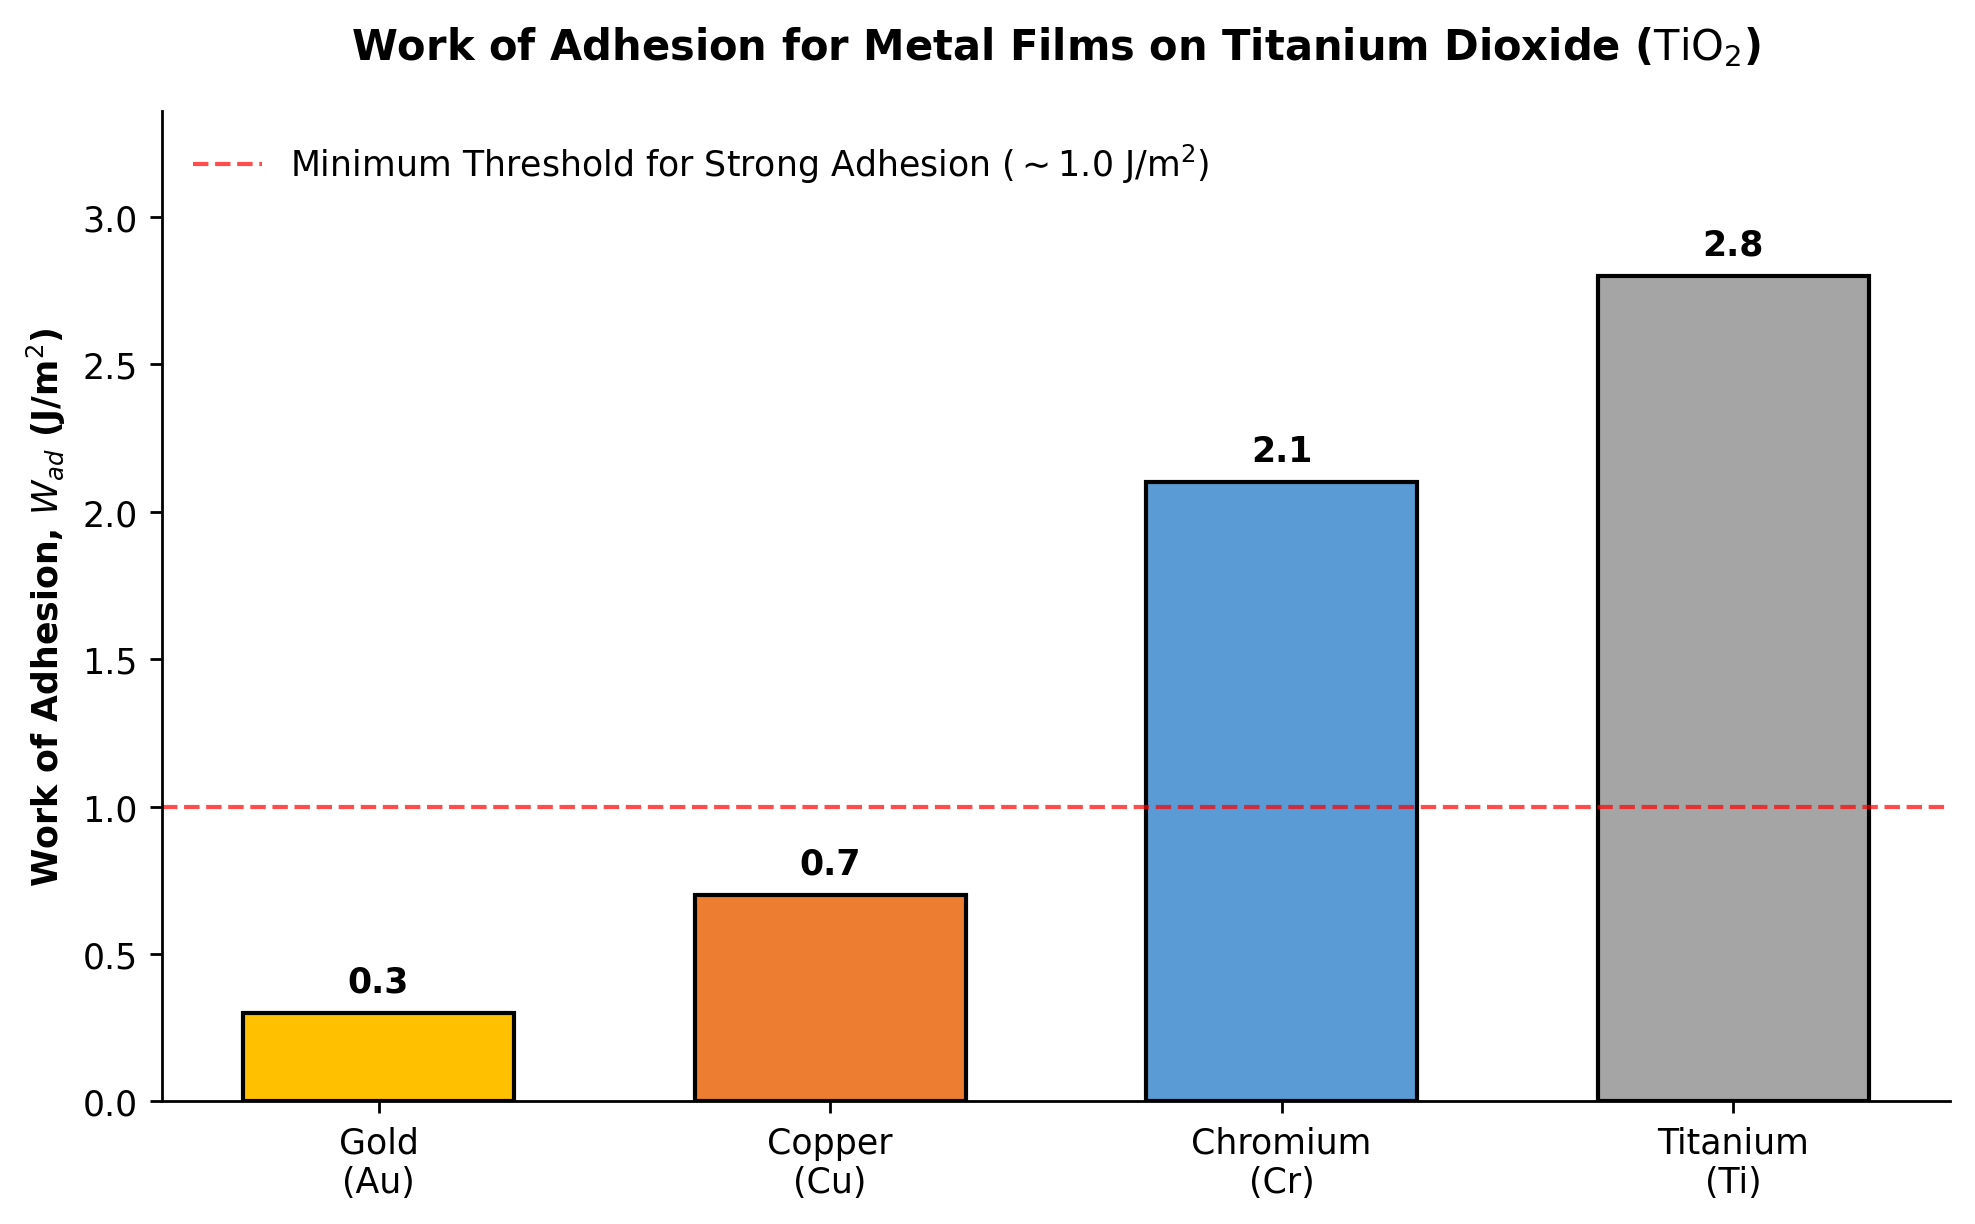

In [8]:
"""
Thermodynamic visualization of the Work of Adhesion for thin films on titanium dioxide.

This module plots the Work of Adhesion (W_ad) for various transition and noble
metals on a titanium dioxide (TiO2) substrate. The analytical framework
demonstrates the necessity of reactive adhesion layers to achieve stable
thin-film deposition by exceeding the minimum empirical adhesion threshold.
"""

# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---

# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#ED7D31', '#5B9BD5', '#A5A5A5']
THRESHOLD_COLOR = 'red'
BAR_WIDTH = 0.6

# Thermodynamic and Material Parameters
LABELS = [
    'Gold\n(Au)',
    'Copper\n(Cu)',
    'Chromium\n(Cr)',
    'Titanium\n(Ti)'
]
# Empirical Work of Adhesion values (J/m^2) for metals on Titanium Dioxide (TiO2)
W_AD_VALUES = [0.3, 0.7, 2.1, 2.8]
ADHESION_THRESHOLD = 1.0

# Textual Plot Elements
PLOT_TITLE = 'Work of Adhesion for Metal Films on Titanium Dioxide ($\\text{TiO}_2$)'
Y_AXIS_LABEL = 'Work of Adhesion, $W_{ad}$ (J/m$^2$)'
THRESHOLD_LABEL = 'Minimum Threshold for Strong Adhesion ($\\sim 1.0$ J/m$^2$)'

# ------------------------------

def plot_work_of_adhesion_titania() -> None:
    """
    Generates and displays a bar chart comparing the Work of Adhesion
    for different metals on a titanium dioxide substrate.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within computational notebook environments. Data
    represents typical empirical values derived from sessile drop
    contact angle measurements and the fundamental Young-Dupré equation.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    w_ad_array = np.array(W_AD_VALUES)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        w_ad_array,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2,
        width=BAR_WIDTH
    )

    ax.axhline(
        ADHESION_THRESHOLD,
        color=THRESHOLD_COLOR,
        linewidth=1.2,
        linestyle='--',
        alpha=0.7,
        label=THRESHOLD_LABEL
    )

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    ax.set_ylim(0, np.max(w_ad_array) * 1.2)

    for bar, w_ad in zip(bars, w_ad_array):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{w_ad:.1f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_work_of_adhesion_titania()

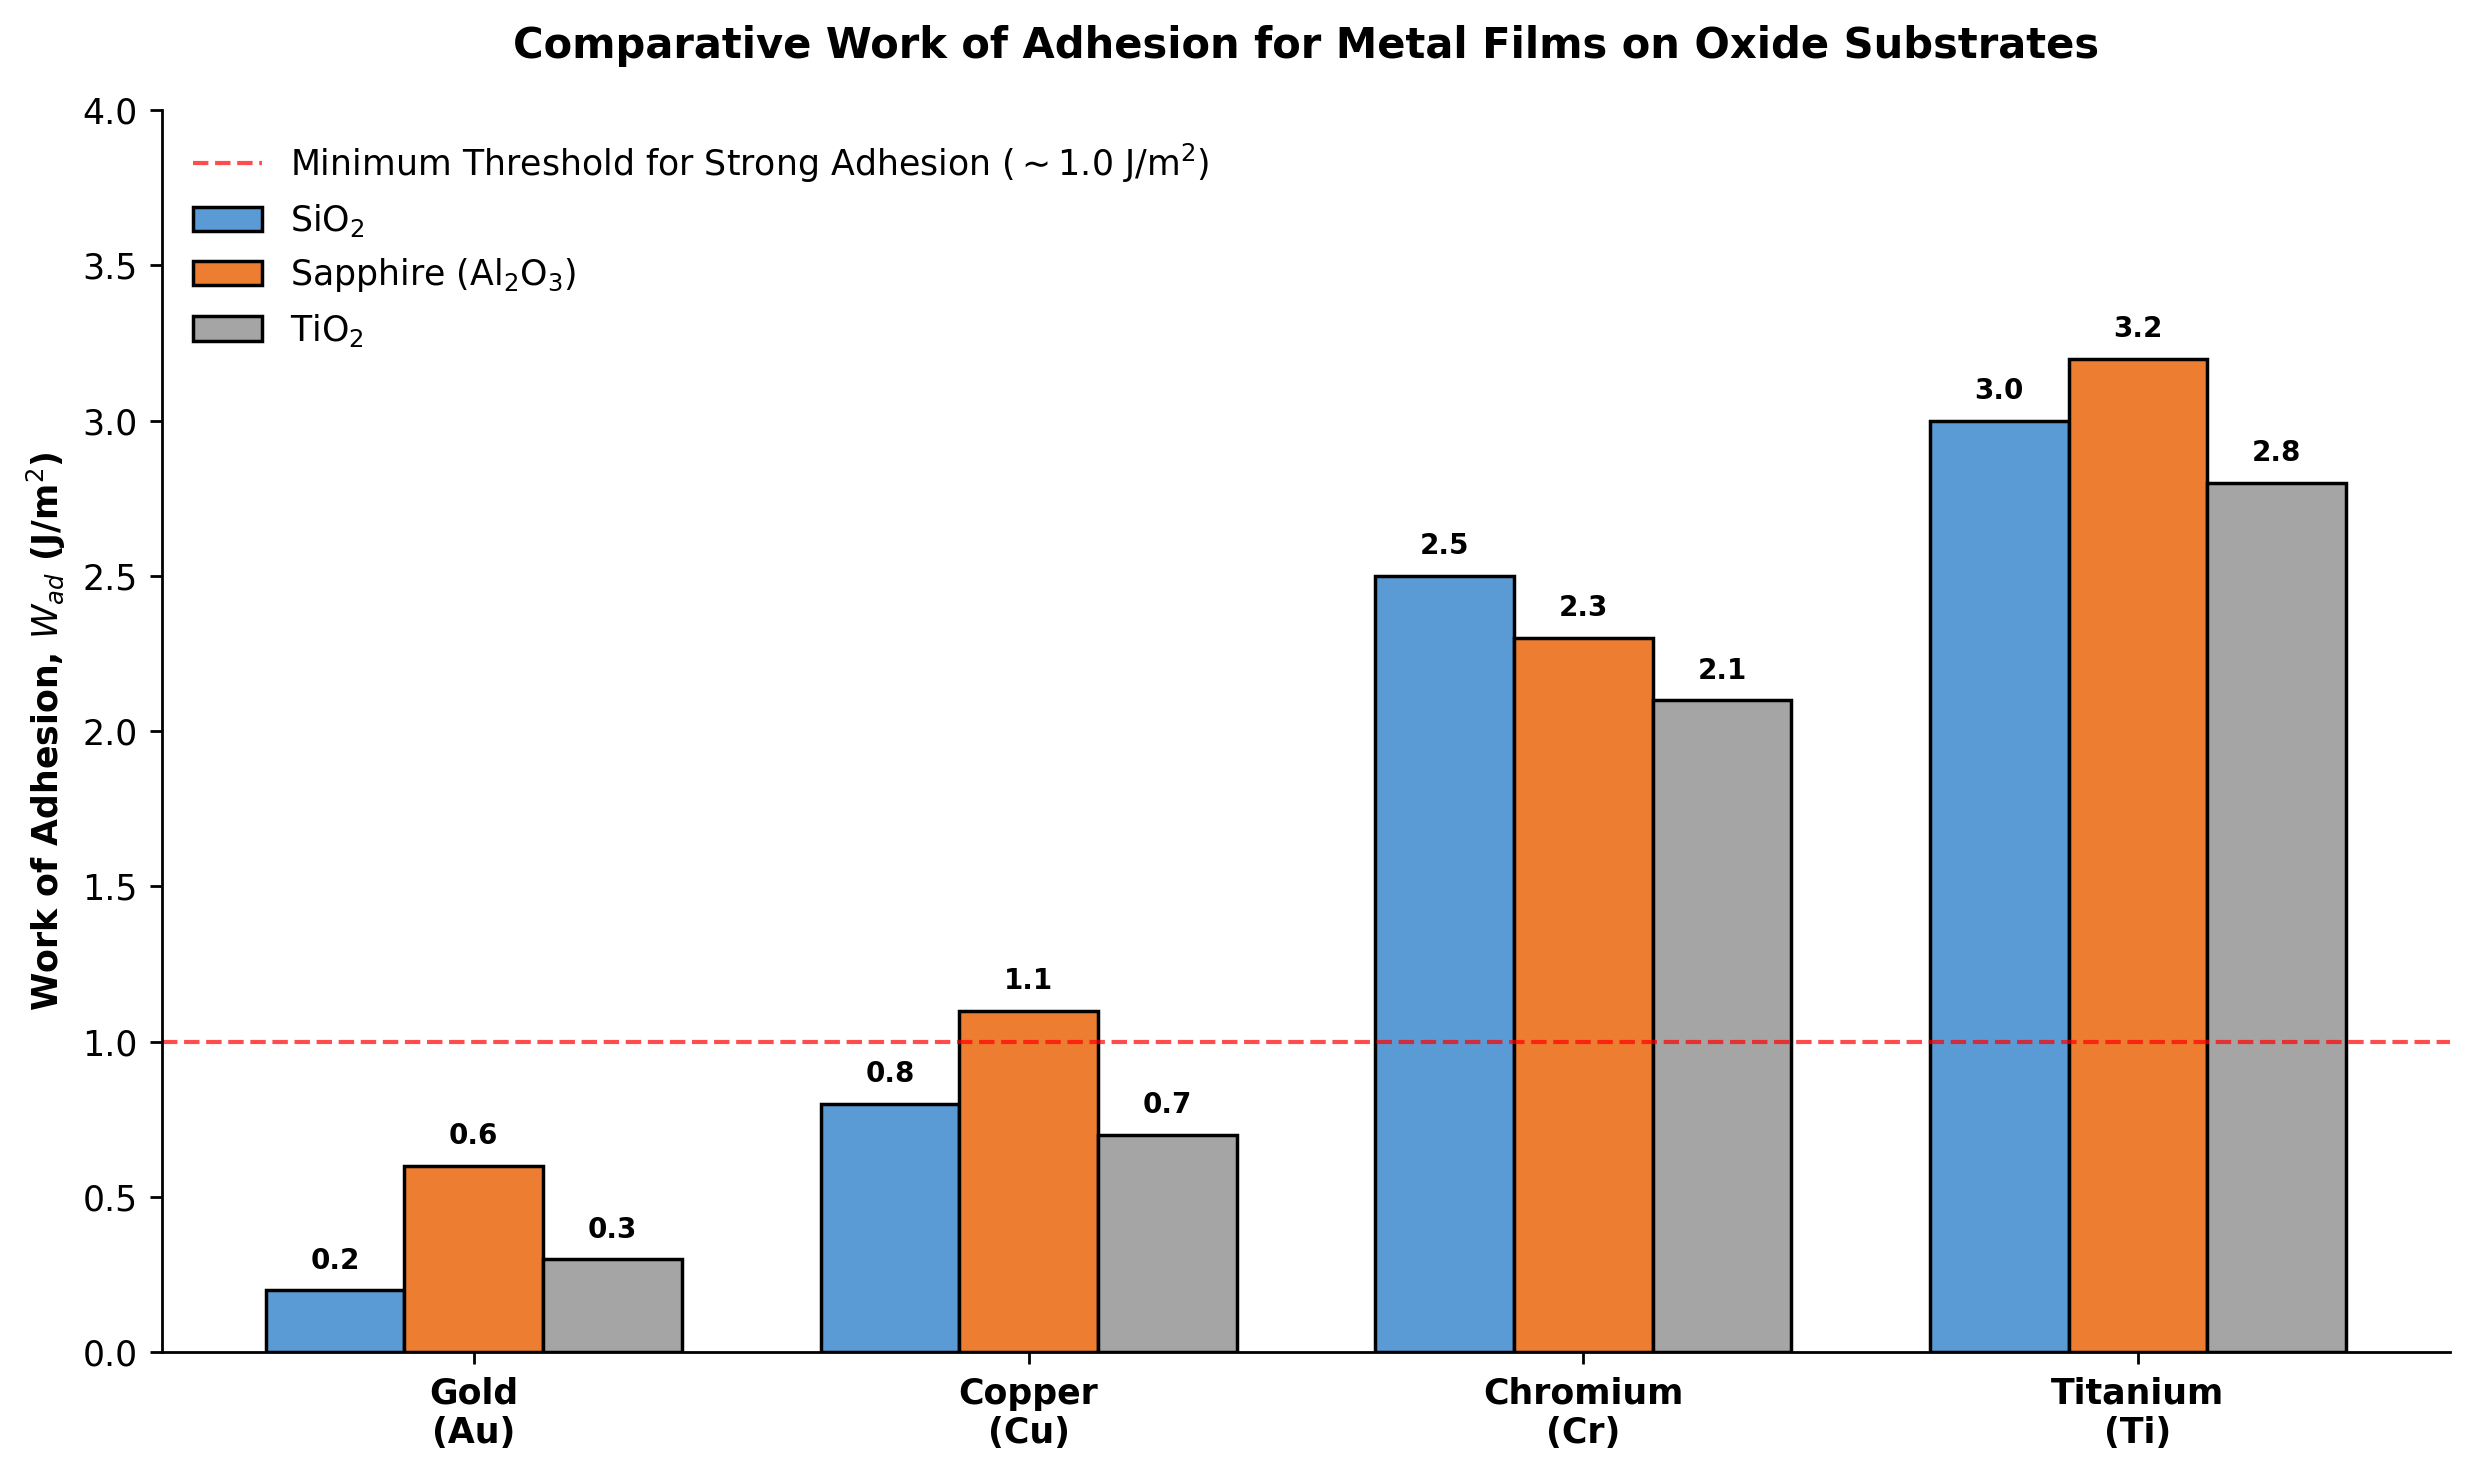

In [9]:
"""
Thermodynamic comparison of the Work of Adhesion across multiple oxide substrates.

This module plots the Work of Adhesion (W_ad) for gold, copper, chromium,
and titanium simultaneously across silicon dioxide, sapphire, and titanium
dioxide substrates. The comparative visualization elucidates the universal
necessity of reactive transition metals for establishing stable thin-film
interfaces across diverse structural ceramics. Results are mostly empirical.
"""

# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---

# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (10, 6)
COLOR_SIO2 = '#5B9BD5'     # Blue
COLOR_AL2O3 = '#ED7D31'    # Orange
COLOR_TIO2 = '#A5A5A5'     # Gray
THRESHOLD_COLOR = 'red'
BAR_WIDTH = 0.25

# Thermodynamic and Material Parameters
LABELS = [
    'Gold\n(Au)',
    'Copper\n(Cu)',
    'Chromium\n(Cr)',
    'Titanium\n(Ti)'
]

# Empirical Work of Adhesion values (J/m^2) for each substrate
W_AD_SIO2 = [0.2, 0.8, 2.5, 3.0]
W_AD_AL2O3 = [0.6, 1.1, 2.3, 3.2]
W_AD_TIO2 = [0.3, 0.7, 2.1, 2.8]

ADHESION_THRESHOLD = 1.0

# Textual Plot Elements
PLOT_TITLE = 'Comparative Work of Adhesion for Metal Films on Oxide Substrates'
Y_AXIS_LABEL = 'Work of Adhesion, $W_{ad}$ (J/m$^2$)'
THRESHOLD_LABEL = 'Minimum Threshold for Strong Adhesion ($\\sim 1.0$ J/m$^2$)'

# ------------------------------

def plot_comparative_work_of_adhesion() -> None:
    """
    Generates and displays a grouped bar chart comparing the Work of Adhesion
    for different metals across three distinct oxide substrates.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. The grouping
    logic aligns related thermodynamic values to facilitate direct visual
    comparisons of substrate-dependent chemical affinities.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    x_indices = np.arange(len(LABELS))

    sio2_array = np.array(W_AD_SIO2)
    al2o3_array = np.array(W_AD_AL2O3)
    tio2_array = np.array(W_AD_TIO2)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars_sio2 = ax.bar(
        x_indices - BAR_WIDTH,
        sio2_array,
        color=COLOR_SIO2,
        edgecolor='black',
        linewidth=1.0,
        width=BAR_WIDTH,
        label='$\\text{SiO}_2$'
    )

    bars_al2o3 = ax.bar(
        x_indices,
        al2o3_array,
        color=COLOR_AL2O3,
        edgecolor='black',
        linewidth=1.0,
        width=BAR_WIDTH,
        label='Sapphire ($\\text{Al}_2\\text{O}_3$)'
    )

    bars_tio2 = ax.bar(
        x_indices + BAR_WIDTH,
        tio2_array,
        color=COLOR_TIO2,
        edgecolor='black',
        linewidth=1.0,
        width=BAR_WIDTH,
        label='$\\text{TiO}_2$'
    )

    ax.axhline(
        ADHESION_THRESHOLD,
        color=THRESHOLD_COLOR,
        linewidth=1.2,
        linestyle='--',
        alpha=0.7,
        label=THRESHOLD_LABEL
    )

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(LABELS, fontweight='bold')

    max_val = max(np.max(sio2_array), np.max(al2o3_array), np.max(tio2_array))
    ax.set_ylim(0, max_val * 1.25)

    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.05,
                f'{height:.1f}',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold',
                rotation=0
            )

    add_value_labels(bars_sio2)
    add_value_labels(bars_al2o3)
    add_value_labels(bars_tio2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    plot_comparative_work_of_adhesion()


Screening adhesion table in J/m^2

metal substrate  true_low  true_high  practical_low  practical_high confidence                                                     mechanism
   Cu     Al2O3       0.4        1.4            0.4            1.75       high     ALD alumina anchor; Cr underlayer improves measured value
   Au     Al2O3       0.5        0.9            1.4            2.90     medium           noble metal; clean dry sapphire can be much tougher
   Cr     Al2O3       1.5        3.5            2.0           15.00     medium   reactive layer; Cr3+ acceptor chemistry can enhance bonding
   Cr      SiO2       1.6        3.8            5.0           25.00     medium      reactive adhesion layer; getter and oxide-bond formation
   Cu      SiO2       0.6        0.9            0.6          100.00     medium        ductile film; practical toughness grows with thickness
   Cu      TiO2       2.3        2.7            2.3            6.00     medium             clean rutile anchor; oxophi

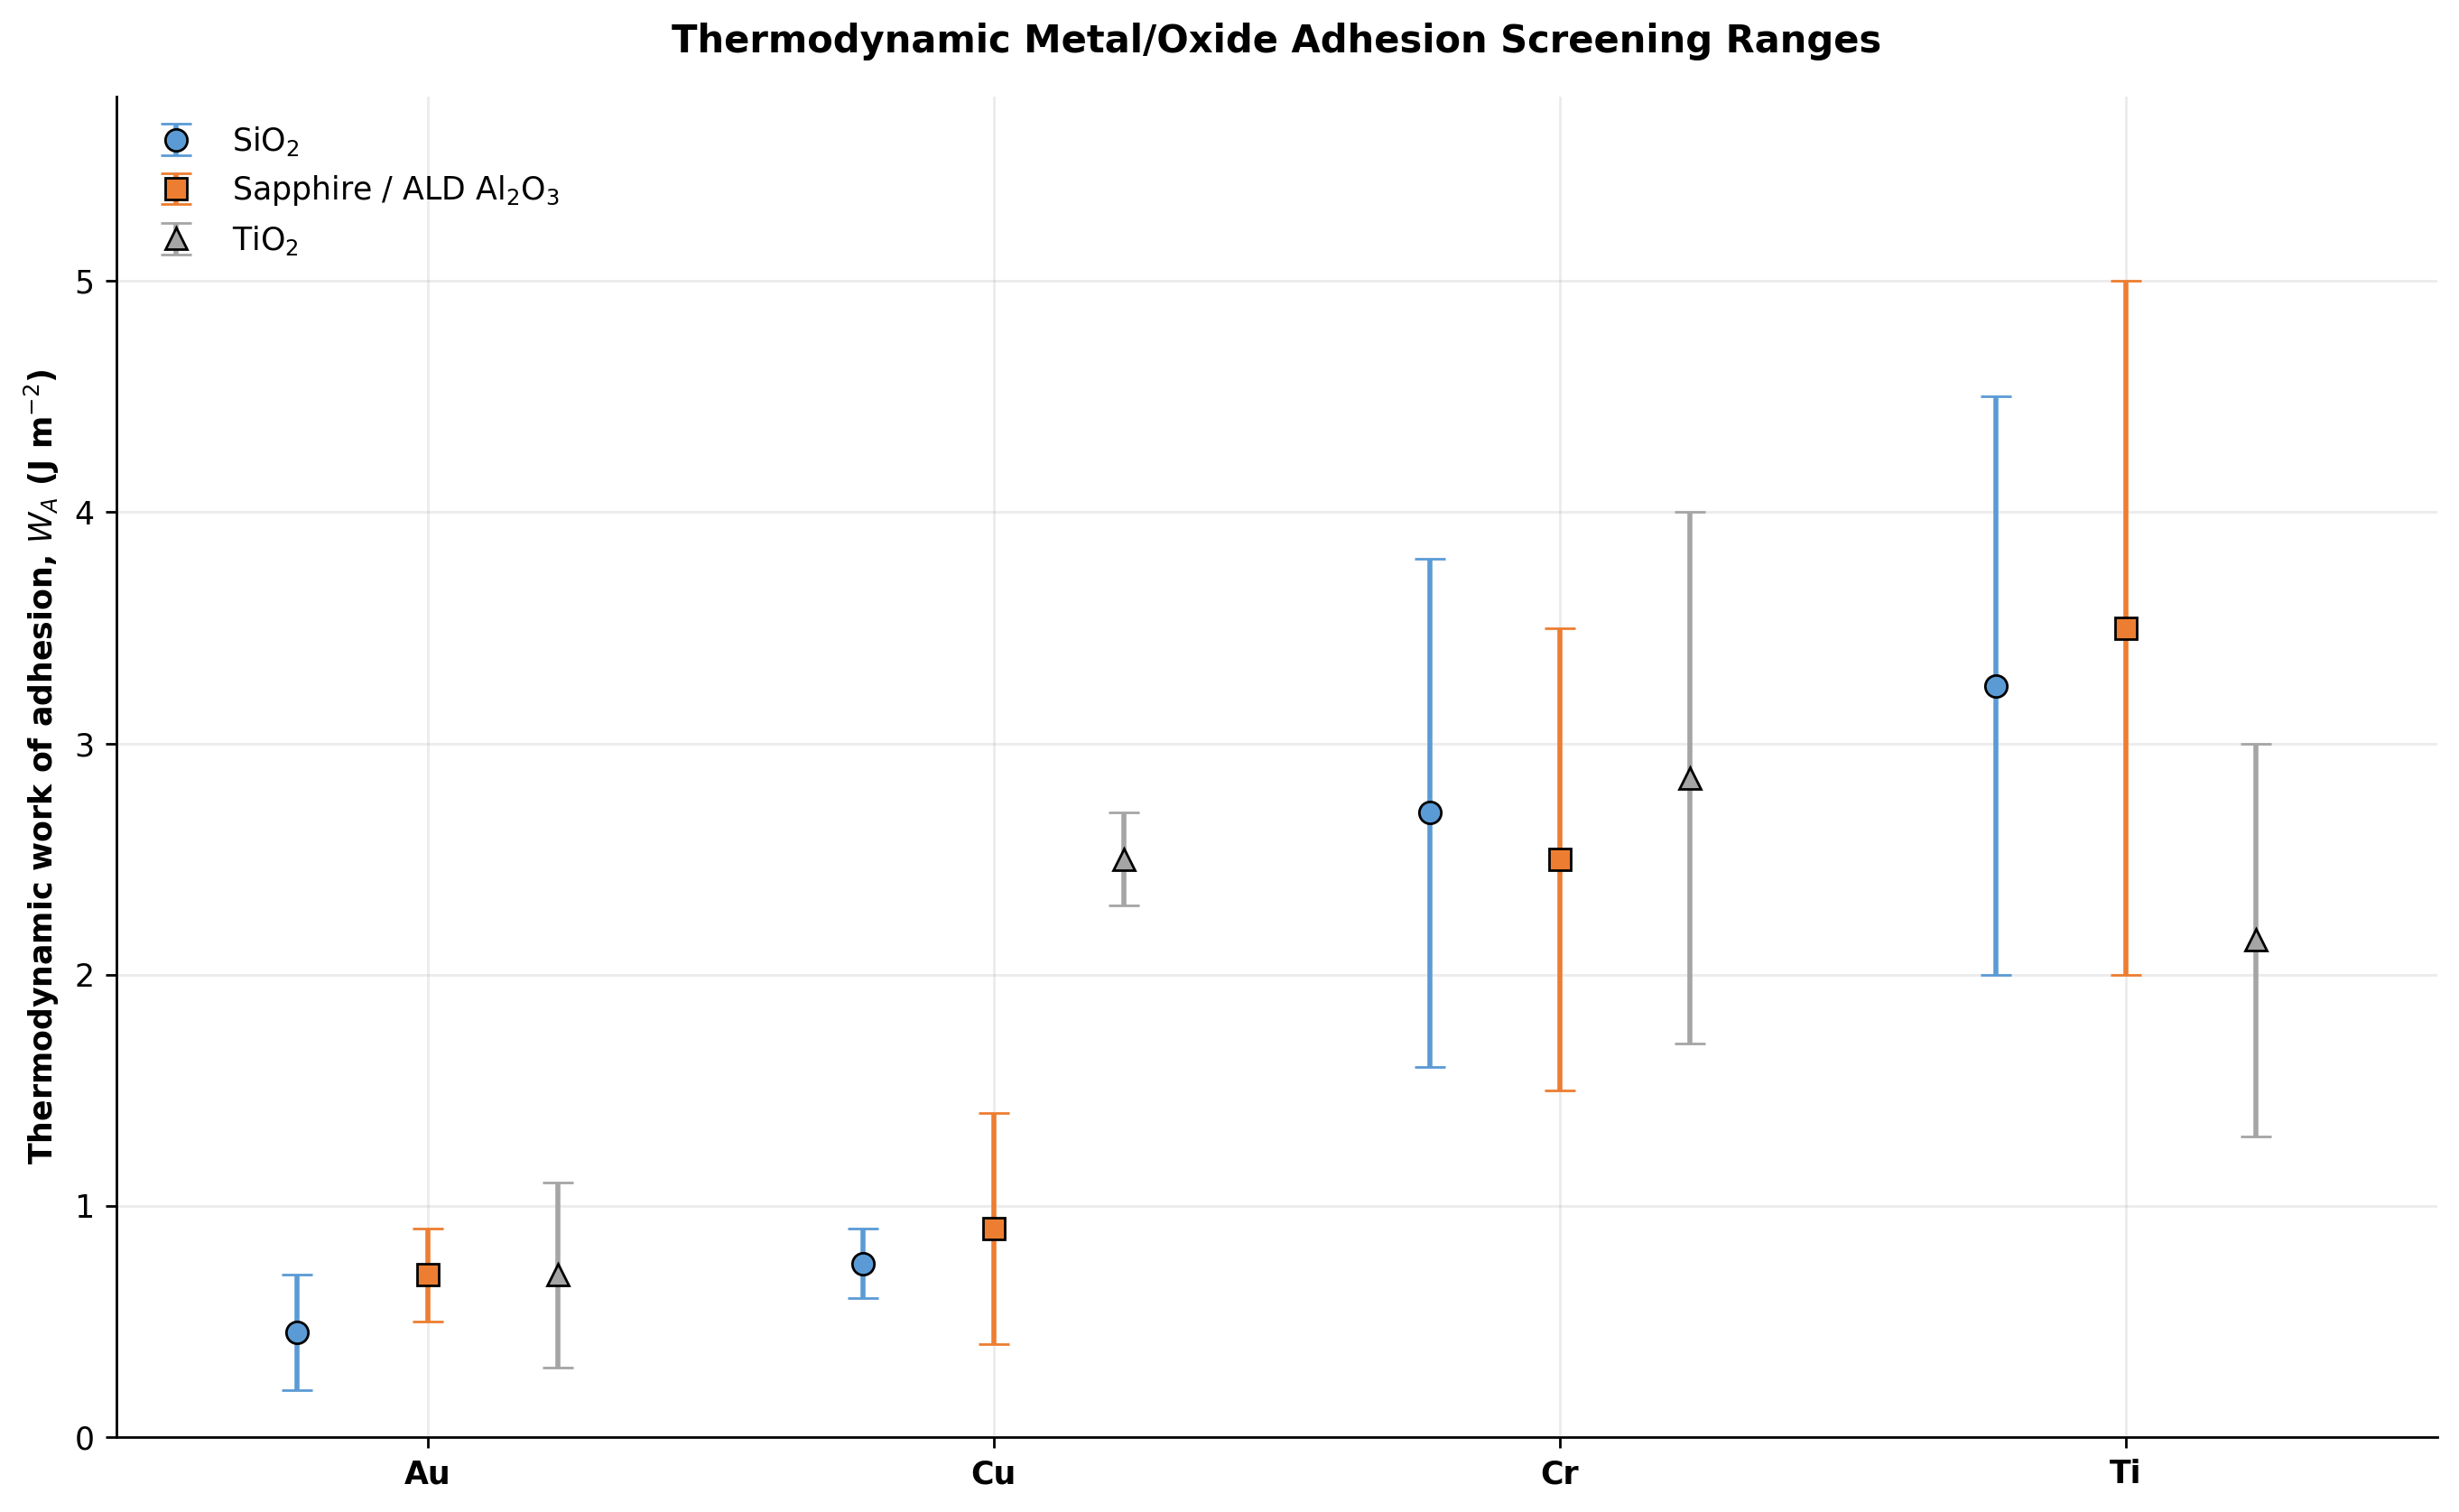

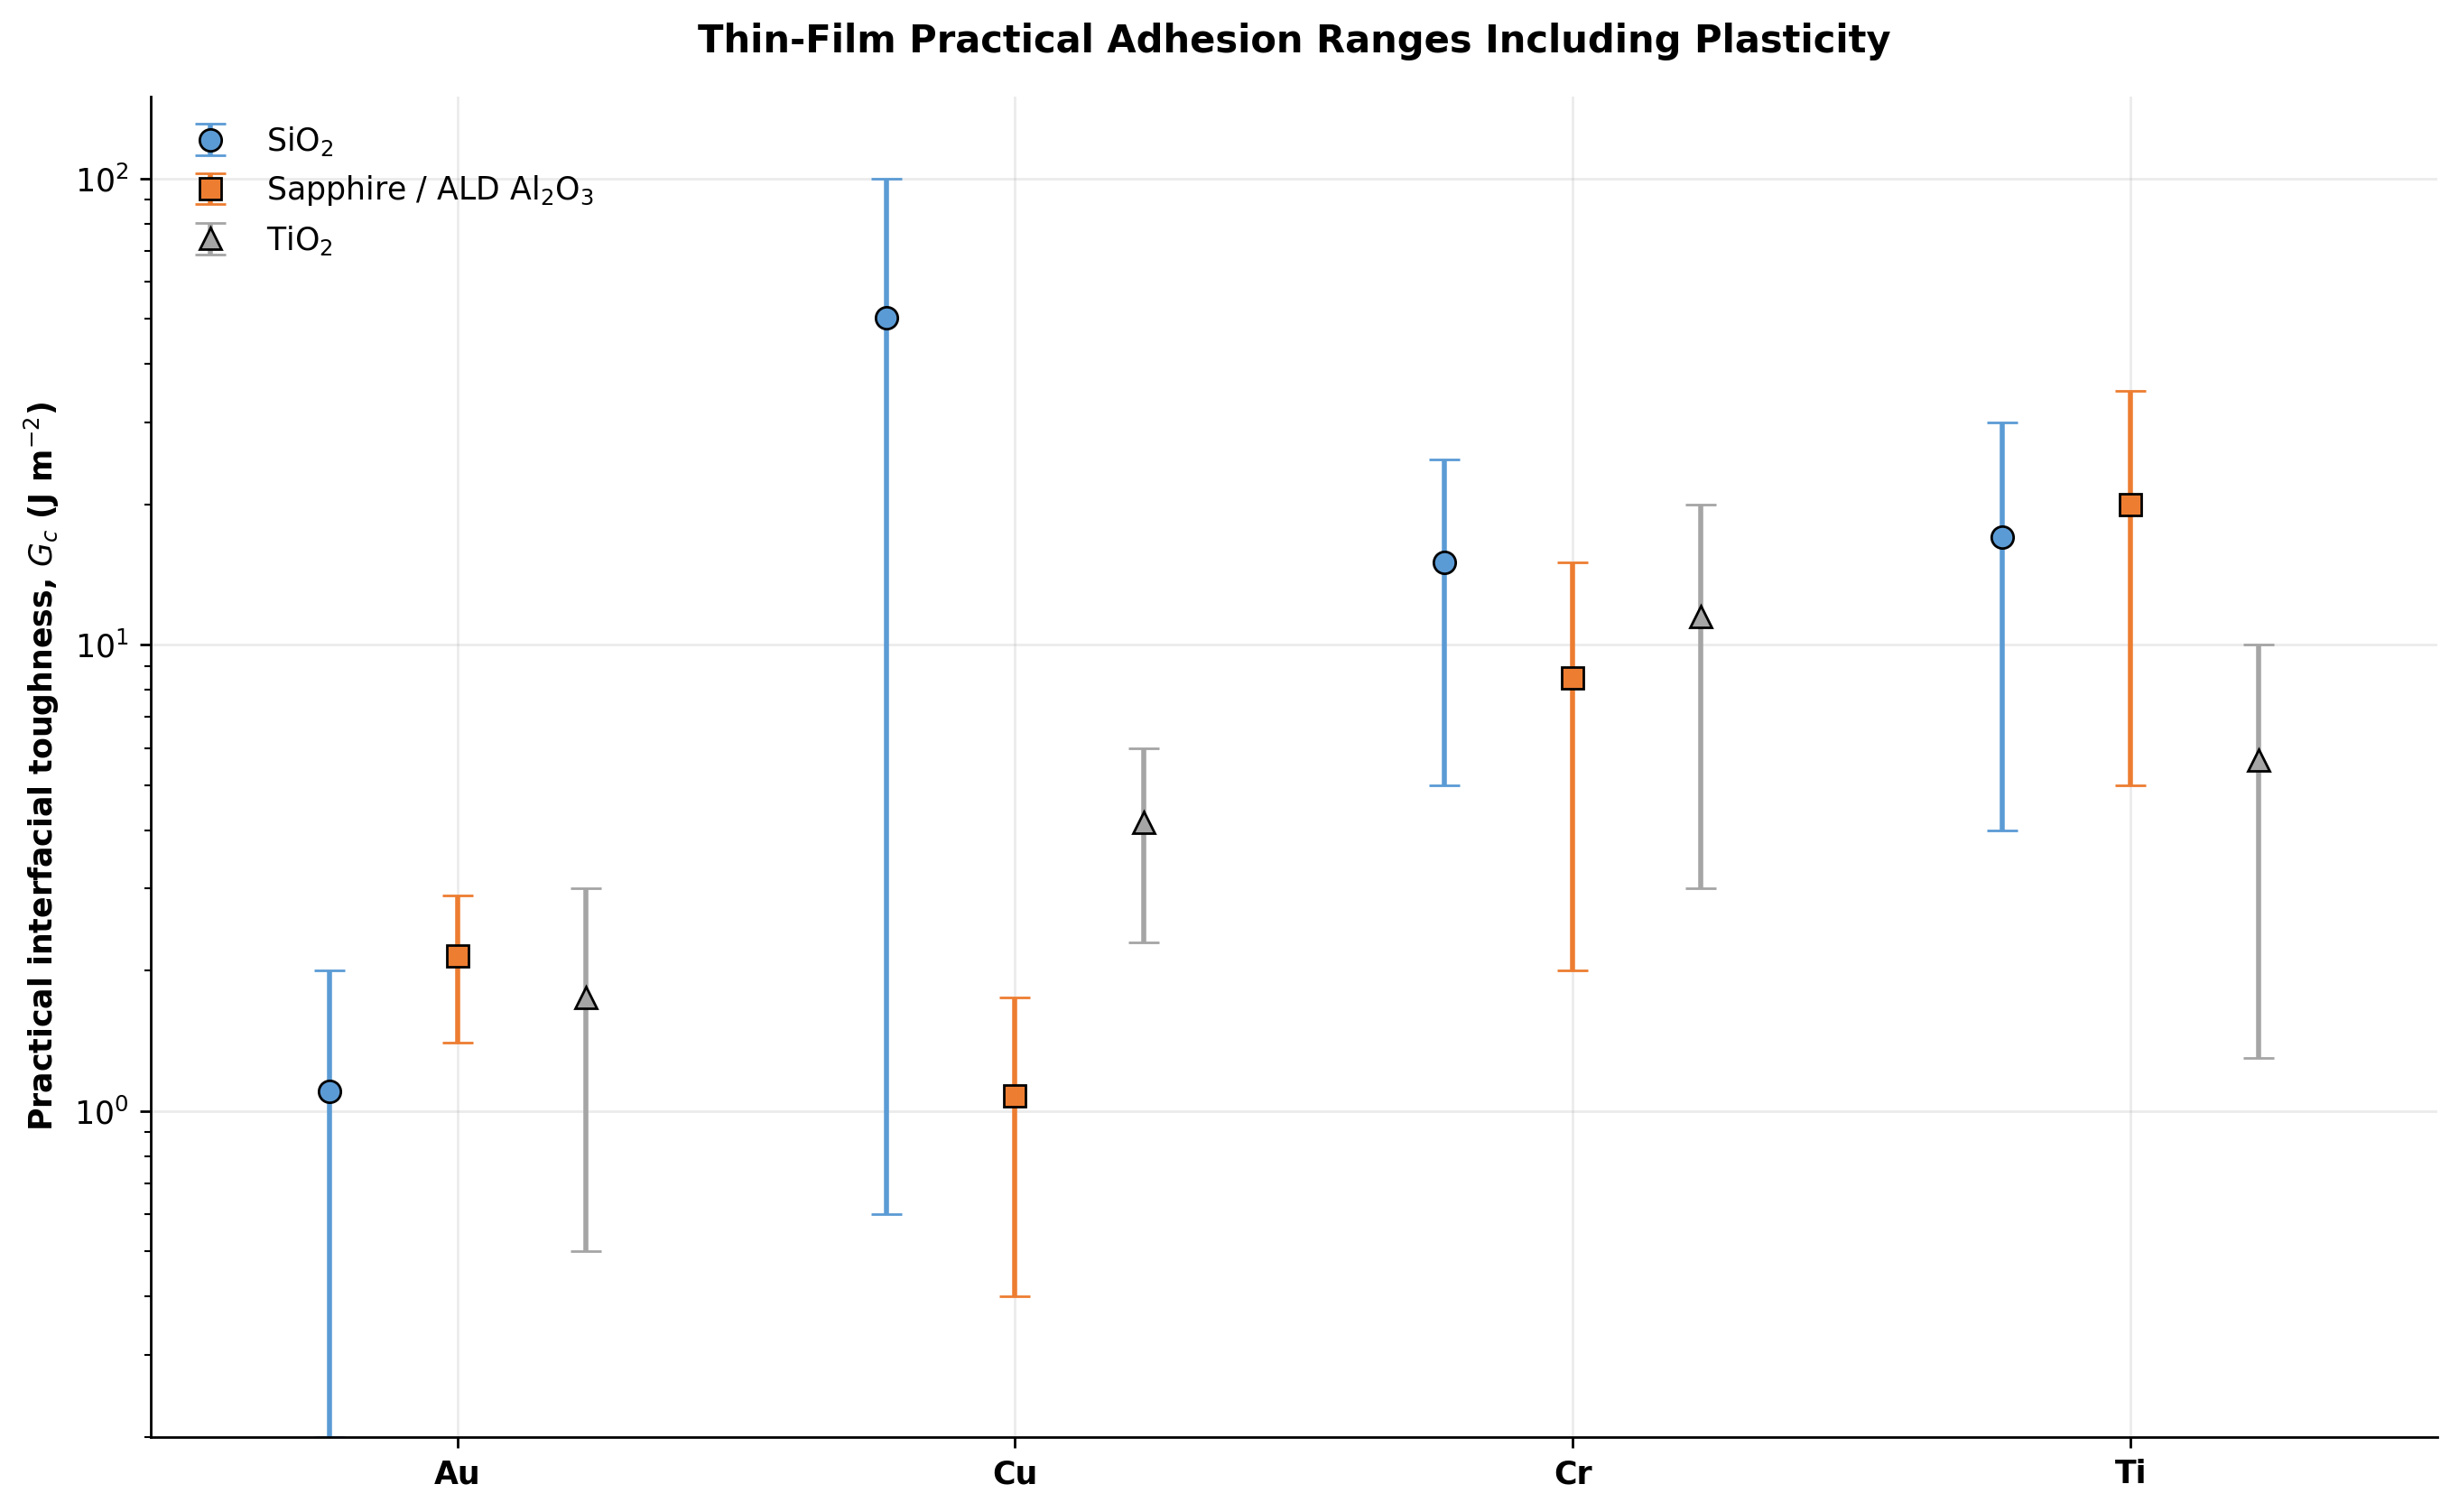

In [13]:
# !pip install -q uv
# !uv pip install --system -q numpy pandas matplotlib

"""Range-based thin-film adhesion screening plots.

The script separates thermodynamic work of adhesion, W_A, from
practical interfacial toughness, G_c. The values are screening ranges
assembled from reported anchors and chemistry-informed priors for
interfaces where surface termination, contamination, oxide hydration,
annealing, and film thickness can change the measured response.
"""

from dataclasses import asdict, dataclass
from typing import Final

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# -----------------------------
# Control knobs
# -----------------------------

MPL_DPI: Final[int] = 250
FIGURE_SIZE: Final[tuple[float, float]] = (11.0, 6.8)
BAR_CAP_SIZE: Final[float] = 5.0
MARKER_SIZE: Final[float] = 7.0
LINE_WIDTH: Final[float] = 1.6
TRUE_WORK_Y_LIMIT: Final[tuple[float, float]] = (0.0, 5.8)
PRACTICAL_Y_LIMIT: Final[tuple[float, float]] = (0.2, 150.0)

METAL_ORDER: Final[list[str]] = ["Au", "Cu", "Cr", "Ti"]

SUBSTRATE_STYLES: Final[dict[str, dict[str, object]]] = {
    "SiO2": {
        "label": r"SiO$_2$",
        "offset": -0.23,
        "marker": "o",
        "color": "#5B9BD5",
    },
    "Al2O3": {
        "label": r"Sapphire / ALD Al$_2$O$_3$",
        "offset": 0.00,
        "marker": "s",
        "color": "#ED7D31",
    },
    "TiO2": {
        "label": r"TiO$_2$",
        "offset": 0.23,
        "marker": "^",
        "color": "#A5A5A5",
    },
}

CONFIDENCE_ORDER: Final[dict[str, int]] = {
    "high": 3,
    "medium": 2,
    "low": 1,
}


@dataclass(frozen=True)
class InterfaceCase:
    """Stores a physically annotated adhesion range for one interface."""

    metal: str
    substrate: str
    true_low: float
    true_high: float
    practical_low: float
    practical_high: float
    confidence: str
    mechanism: str


INTERFACE_CASES: Final[list[InterfaceCase]] = [
    InterfaceCase(
        metal="Au",
        substrate="SiO2",
        true_low=0.20,
        true_high=0.70,
        practical_low=0.20,
        practical_high=2.00,
        confidence="low",
        mechanism="noble metal; weak direct oxide bonding; Cr/Ti usually used",
    ),
    InterfaceCase(
        metal="Au",
        substrate="Al2O3",
        true_low=0.50,
        true_high=0.90,
        practical_low=1.40,
        practical_high=2.90,
        confidence="medium",
        mechanism="noble metal; clean dry sapphire can be much tougher",
    ),
    InterfaceCase(
        metal="Au",
        substrate="TiO2",
        true_low=0.30,
        true_high=1.10,
        practical_low=0.50,
        practical_high=3.00,
        confidence="low",
        mechanism="noble metal on reducible oxide; termination sensitive",
    ),
    InterfaceCase(
        metal="Cu",
        substrate="SiO2",
        true_low=0.60,
        true_high=0.90,
        practical_low=0.60,
        practical_high=100.00,
        confidence="medium",
        mechanism="ductile film; practical toughness grows with thickness",
    ),
    InterfaceCase(
        metal="Cu",
        substrate="Al2O3",
        true_low=0.40,
        true_high=1.40,
        practical_low=0.40,
        practical_high=1.75,
        confidence="high",
        mechanism="ALD alumina anchor; Cr underlayer improves measured value",
    ),
    InterfaceCase(
        metal="Cu",
        substrate="TiO2",
        true_low=2.30,
        true_high=2.70,
        practical_low=2.30,
        practical_high=6.00,
        confidence="medium",
        mechanism="clean rutile anchor; oxophilicity-linked adhesion",
    ),
    InterfaceCase(
        metal="Cr",
        substrate="SiO2",
        true_low=1.60,
        true_high=3.80,
        practical_low=5.00,
        practical_high=25.00,
        confidence="medium",
        mechanism="reactive adhesion layer; getter and oxide-bond formation",
    ),
    InterfaceCase(
        metal="Cr",
        substrate="Al2O3",
        true_low=1.50,
        true_high=3.50,
        practical_low=2.00,
        practical_high=15.00,
        confidence="medium",
        mechanism="reactive layer; Cr3+ acceptor chemistry can enhance bonding",
    ),
    InterfaceCase(
        metal="Cr",
        substrate="TiO2",
        true_low=1.70,
        true_high=4.00,
        practical_low=3.00,
        practical_high=20.00,
        confidence="low",
        mechanism="reactive metal on reducible oxide; process sensitive",
    ),
    InterfaceCase(
        metal="Ti",
        substrate="SiO2",
        true_low=2.00,
        true_high=4.50,
        practical_low=4.00,
        practical_high=30.00,
        confidence="medium",
        mechanism="strong oxygen affinity; silicide/oxide interphase possible",
    ),
    InterfaceCase(
        metal="Ti",
        substrate="Al2O3",
        true_low=2.00,
        true_high=5.00,
        practical_low=5.00,
        practical_high=35.00,
        confidence="medium",
        mechanism="reactive adhesion layer; interfacial reaction products matter",
    ),
    InterfaceCase(
        metal="Ti",
        substrate="TiO2",
        true_low=1.30,
        true_high=3.00,
        practical_low=1.30,
        practical_high=10.00,
        confidence="medium",
        mechanism="chemically compatible; termination and bond density matter",
    ),
]


def configure_matplotlib() -> None:
    """Configure rendering for notebook-quality figures."""

    mpl.rcParams["figure.dpi"] = MPL_DPI
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
    mpl.rcParams["axes.titleweight"] = "bold"
    mpl.rcParams["axes.labelweight"] = "bold"
    mpl.rcParams["axes.grid"] = True
    mpl.rcParams["grid.alpha"] = 0.25


def build_interface_table() -> pd.DataFrame:
    """Return the interface table with midpoint and range columns."""

    rows = [asdict(case) for case in INTERFACE_CASES]
    table = pd.DataFrame(rows)

    table["true_mid"] = 0.5 * (table["true_low"] + table["true_high"])
    table["practical_mid"] = 0.5 * (
        table["practical_low"] + table["practical_high"]
    )
    table["confidence_rank"] = table["confidence"].map(CONFIDENCE_ORDER)

    return table.sort_values(
        by=["confidence_rank", "metal", "substrate"],
        ascending=[False, True, True],
    )


def get_range_arrays(
    data: pd.DataFrame,
    low_column: str,
    high_column: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert lower and upper bounds into centers and asymmetric errors."""

    low_values = data[low_column].to_numpy(dtype=float)
    high_values = data[high_column].to_numpy(dtype=float)
    centers = 0.5 * (low_values + high_values)

    lower_errors = centers - low_values
    upper_errors = high_values - centers
    errors = np.vstack((lower_errors, upper_errors))

    return centers, errors


def plot_metric_ranges(
    table: pd.DataFrame,
    low_column: str,
    high_column: str,
    y_label: str,
    title: str,
    y_limits: tuple[float, float],
    use_log_scale: bool = False,
) -> None:
    """Render one range plot for the selected adhesion metric."""

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    x_base = np.arange(len(METAL_ORDER), dtype=float)

    for substrate, style in SUBSTRATE_STYLES.items():
        subset = table[table["substrate"] == substrate].copy()
        subset["metal_index"] = subset["metal"].map(
            {metal: idx for idx, metal in enumerate(METAL_ORDER)}
        )
        subset = subset.sort_values("metal_index")

        x_positions = (
            subset["metal_index"].to_numpy(dtype=float)
            + float(style["offset"])
        )
        centers, errors = get_range_arrays(
            subset,
            low_column=low_column,
            high_column=high_column,
        )

        ax.errorbar(
            x_positions,
            centers,
            yerr=errors,
            fmt=str(style["marker"]),
            markersize=MARKER_SIZE,
            capsize=BAR_CAP_SIZE,
            elinewidth=LINE_WIDTH,
            linewidth=LINE_WIDTH,
            color=str(style["color"]),
            markeredgecolor="black",
            markeredgewidth=0.8,
            label=str(style["label"]),
        )

    ax.set_title(title, pad=14)
    ax.set_ylabel(y_label)
    ax.set_xticks(x_base)
    ax.set_xticklabels(METAL_ORDER, fontweight="bold")
    ax.set_xlim(-0.55, len(METAL_ORDER) - 0.45)
    ax.set_ylim(*y_limits)

    if use_log_scale:
        ax.set_yscale("log")
        ax.set_ylim(*y_limits)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, loc="upper left")
    plt.tight_layout()
    plt.show()


def main() -> pd.DataFrame:
    """Build the adhesion table and render the screening plots."""

    configure_matplotlib()
    table = build_interface_table()

    display_columns = [
        "metal",
        "substrate",
        "true_low",
        "true_high",
        "practical_low",
        "practical_high",
        "confidence",
        "mechanism",
    ]

    print("\nScreening adhesion table in J/m^2\n")
    print(table[display_columns].to_string(index=False))

    plot_metric_ranges(
        table=table,
        low_column="true_low",
        high_column="true_high",
        y_label=r"Thermodynamic work of adhesion, $W_A$ (J m$^{-2}$)",
        title="Thermodynamic Metal/Oxide Adhesion Screening Ranges",
        y_limits=TRUE_WORK_Y_LIMIT,
        use_log_scale=False,
    )

    plot_metric_ranges(
        table=table,
        low_column="practical_low",
        high_column="practical_high",
        y_label=r"Practical interfacial toughness, $G_c$ (J m$^{-2}$)",
        title="Thin-Film Practical Adhesion Ranges Including Plasticity",
        y_limits=PRACTICAL_Y_LIMIT,
        use_log_scale=True,
    )

    return table


if __name__ == "__main__":
    adhesion_table = main()

---

### Thermodynamic Work of Adhesion Across Metal-Oxide Interfaces

Non-reactive noble and semi-noble metals, such as gold and copper, exhibit relatively poor chemical affinity for structural ceramics. Experimental measurements place the true thermodynamic work of adhesion for copper on silicon dioxide at approximately 0.8 J/m², and gold on sapphire (aluminum oxide) between 0.5 and 0.9 J/m² (Volinsky et al., 2002). Tight-binding and theoretical models further demonstrate that the lack of charge transfer and localized bonding at the interface restricts the adhesive strength of these non-transition and late-transition metals on alumina (Alemany et al., 1993).

Conversely, reactive transition metals like chromium and titanium are universally employed as adhesion layers because they establish strong chemical bonds across the metal-ceramic interface. Incorporating a titanium or chromium layer significantly improves interfacial fracture resistance, acting as a gettering agent and increasing the practical and thermodynamic adhesion energy, frequently by a factor of up to ten compared to bare gold (Evans et al., 1999; Lewis et al., 2013). Blister testing assessments also quantitatively confirm this trend, showing elevated debonding energies for chromium layers relative to pure copper or platinum on aluminum oxide substrates (Berdova et al., 2013).

---

**References**

Alemany, P., Boorse, R. S., Burlitch, J. M., & Hoffmann, R. (1993). Theoretical study of transition-metal adhesion on doped alumina. *Chemistry of Materials*, *5*(4), 465–471. [https://doi.org/10.1021/cm00028a012](https://www.google.com/search?q=https://doi.org/10.1021/cm00028a012)

Berdova, M., Lyytinen, J., Grigoras, K., Baby, A., Kilpi, L., Ronkainen, H., Franssila, S., & Koskinen, J. (2013). Characterization of thin film adhesion by MEMS shaft-loading blister testing. *Journal of Vacuum Science & Technology A: Vacuum, Surfaces, and Films*, *31*(3). [https://doi.org/10.1116/1.4801921]()

Evans, A. G., Hutchinson, J. W., & Wei, Y. (1999). Interface adhesion: effects of plasticity and segregation. *Acta Materialia*, *47*(15), 4093–4113. [https://doi.org/10.1016/s1359-6454(99)00269-4]()

Lewis, A. P., Down, M. P., Chianrabutra, C., Jiang, L., McBride, J. W., & Spearing, S. M. (2013). The Effect on Switching Lifetime of Chromium Adhesion Layers in Gold-Coated Electrical Contacts under Cold and Hot Switching Conditions. *2013 IEEE 59th Holm Conference on Electrical Contacts (Holm 2013)*, 1–7. [https://doi.org/10.1109/holm.2013.6651433]()

Volinsky, A. A., Moody, N. R., & Gerberich, W. W. (2002). Interfacial toughness measurements for thin films on substrates. *Acta Materialia*, *50*(2), 441–466. [https://doi.org/10.1016/s1359-6454(01)00354-8]()